In [ ]:
pip uninstall antspyx -y

Found existing installation: antspyx 0.6.3
Uninstalling antspyx-0.6.3:
  Successfully uninstalled antspyx-0.6.3
Note: you may need to restart the kernel to use updated packages.


In [ ]:
pip install --no-cache-dir antspyx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 98.4 MB/s  0:00:00 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.


In [ ]:
!pip install nibabel

In [ ]:
!pip install opencv-python

In [ ]:
import ants
print(ants.__file__)
print(dir(ants))

/root/miniconda3/envs/py3.10/lib/python3.10/site-packages/ants/__init__.py
['ANTsImage', 'ANTsTransform', 'Affine3D', 'BlurIntensity', 'CastIntensity', 'FlipImage', 'LocallyBlurIntensity', 'MultiResolutionImage', 'NormalizeIntensity', 'RandomRotate2D', 'RandomRotate3D', 'RandomShear2D', 'RandomShear3D', 'RandomTranslate2D', 'RandomTranslate3D', 'RandomZoom2D', 'RandomZoom3D', 'RescaleIntensity', 'Rotate2D', 'Rotate3D', 'ScaleImage', 'Shear2D', 'Shear3D', 'ShiftScaleIntensity', 'SigmoidIntensity', 'Translate2D', 'Translate3D', 'TranslateImage', 'Zoom2D', 'Zoom3D', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '__version__', 'abp_n4', 'add_noise_to_image', 'affine2d', 'affine3d', 'affine_initializer', 'allclose', 'anti_alias', 'ants_image', 'ants_image_io', 'ants_metric', 'ants_metric_io', 'ants_transform', 'ants_transform_io', 'apply_ants_transform', 'apply_ants_transform_to_image', 'apply_ants_transform_to_point', 

In [ ]:
import os
import glob
import ants
import nibabel as nib
import numpy as np
import cv2
import torch
from tqdm import tqdm

# ---------- SETTINGS ----------
DATA_ROOT = "jl_fs/mri_data"
SAVE_PATH = "jl_fs/mri_data/paired_mri.pt"
IMG_SIZE = 256
print('reaching here')
# ---------- NORMALIZATION ----------
def normalize(x):
    return (x - x.mean()) / (x.std() + 1e-8)

# ---------- FIND FILE ----------
def get_nii_file(folder):
    files = glob.glob(os.path.join(folder, "*.nii.gz"))
    return files[0] if files else None

# ---------- MAIN ----------
dataset = []

patients = sorted(os.listdir(DATA_ROOT))
print(patients)
for patient in tqdm(patients):

    try:
        path_3t = get_nii_file(os.path.join(DATA_ROOT, patient, "ses-1", "anat"))
        path_7t = get_nii_file(os.path.join(DATA_ROOT, patient, "ses-2", "anat"))

        if path_3t is None or path_7t is None:
            continue

        # -------- LOAD --------
        print('Load the nii.gz file')
        fixed = ants.image_read(path_7t)   # 7T
        moving = ants.image_read(path_3t)  # 3T

        # -------- REGISTER --------
        result = ants.registration(
            fixed=fixed,
            moving=moving,
            type_of_transform='SyN',
            aff_metric='mattes',
            syn_metric='mattes'
        )

        reg_3t = result['warpedmovout']

        img_3t = reg_3t.numpy()
        img_7t = fixed.numpy()

        # -------- NORMALIZE --------
        img_3t = normalize(img_3t)
        img_7t = normalize(img_7t)

        H, W, D = img_3t.shape

        # -------- AXIAL --------
        for i in range(int(0.2*D), int(0.8*D)):
            s3 = img_3t[:, :, i]
            s7 = img_7t[:, :, i]

            if s3.mean() < 0.01:
                continue

            s3 = cv2.resize(s3, (IMG_SIZE, IMG_SIZE))
            s7 = cv2.resize(s7, (IMG_SIZE, IMG_SIZE))

            dataset.append((s3[None], s7[None]))

        # -------- CORONAL --------
        for i in range(int(0.2*W), int(0.8*W)):
            s3 = img_3t[:, i, :]
            s7 = img_7t[:, i, :]

            if s3.mean() < 0.01:
                continue

            s3 = cv2.resize(s3, (IMG_SIZE, IMG_SIZE))
            s7 = cv2.resize(s7, (IMG_SIZE, IMG_SIZE))

            dataset.append((s3[None], s7[None]))

        # -------- SAGITTAL --------
        for i in range(int(0.2*H), int(0.8*H)):
            s3 = img_3t[i, :, :]
            s7 = img_7t[i, :, :]

            if s3.mean() < 0.01:
                continue

            s3 = cv2.resize(s3, (IMG_SIZE, IMG_SIZE))
            s7 = cv2.resize(s7, (IMG_SIZE, IMG_SIZE))

            dataset.append((s3[None], s7[None]))

    except Exception as e:
        print(f"Error in {patient}: {e}")

# ---------- SAVE ----------
print(f"Total samples: {len(dataset)}")

torch.save(dataset, SAVE_PATH)
print("Dataset saved!")

reaching here
['.ipynb_checkpoints', 'paired_mri.pt', 'sub-1', 'sub-10', 'sub-2', 'sub-3', 'sub-4', 'sub-5', 'sub-6', 'sub-7', 'sub-8', 'sub-9']


  0%|          | 0/12 [00:00<?, ?it/s]

Load the nii.gz file


 25%|██▌       | 3/12 [01:01<03:05, 20.63s/it]

Load the nii.gz file
Error in sub-10: Could not create ImageIO object for file jl_fs/mri_data/sub-10/ses-2/anat/sub-10_ses-2_T1w_defaced.nii.gz
Load the nii.gz file


...

Load the nii.gz file


 92%|█████████▏| 11/12 [08:10<00:56, 56.24s/it]

Load the nii.gz file


100%|██████████| 12/12 [09:12<00:00, 46.04s/it]


Total samples: 3968
Dataset saved!


7936
abc


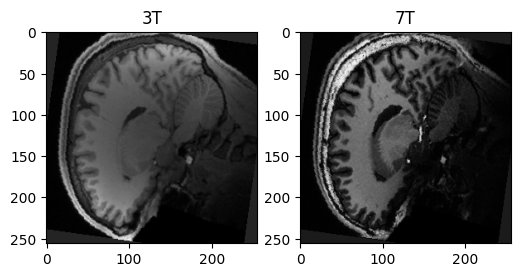

abc


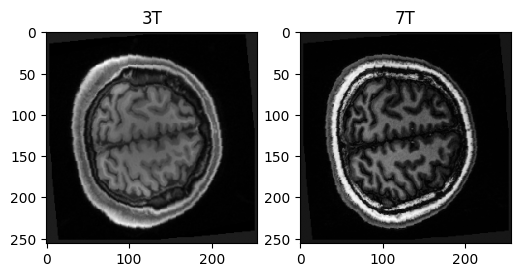

abc


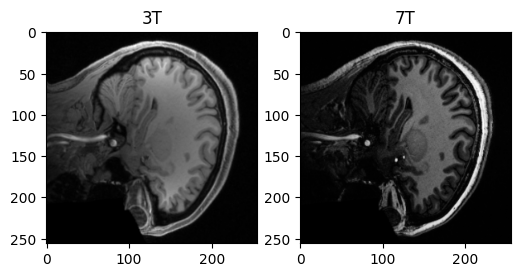

abc


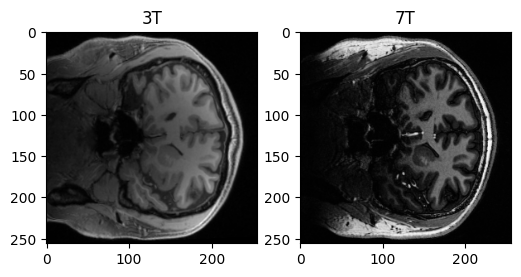

abc


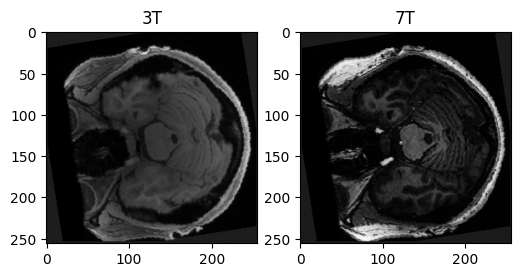

In [ ]:
import torch
import matplotlib.pyplot as plt
import random

data = torch.load("jl_fs/mri_data/paired_mri_augmented.pt",weights_only=False)
print(len(data))
for _ in range(5):
    x, y = random.choice(data)
    print('abc')
    plt.figure(figsize=(6,3))

    plt.subplot(1,2,1)
    plt.imshow(x[0], cmap='gray')
    plt.title("3T")

    plt.subplot(1,2,2)
    plt.imshow(y[0], cmap='gray')
    plt.title("7T")

    plt.show()

In [ ]:
import torch
import random
import torchvision.transforms.functional as TF

data = torch.load("jl_fs/mri_data/paired_mri.pt", weights_only=False)
print("Original size:", len(data))

Original size: 3968


In [ ]:
def augment_pair(x, y):
    x = torch.tensor(x)
    y = torch.tensor(y)

    # ---- Flip ----
    if random.random() > 0.5:
        x = TF.hflip(x)
        y = TF.hflip(y)

    # ---- Rotation ----
    angle = random.uniform(-10, 10)
    x = TF.rotate(x, angle)
    y = TF.rotate(y, angle)

    # ---- Slight zoom ----
    scale = random.uniform(0.95, 1.05)
    x = TF.affine(x, angle=0, translate=[0,0], scale=scale, shear=0)
    y = TF.affine(y, angle=0, translate=[0,0], scale=scale, shear=0)

    return x.numpy(), y.numpy()

In [ ]:
augmented_data = []

for (x, y) in data:

    # keep original
    augmented_data.append((x, y))

    # add ONE augmented version
    x_aug, y_aug = augment_pair(x, y)
    augmented_data.append((x_aug, y_aug))

print("Final dataset size:", len(augmented_data))

Final dataset size: 7936


In [ ]:
torch.save(augmented_data, "jl_fs/mri_data/paired_mri_augmented.pt")
print("Saved successfully!")

Saved successfully!


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import os
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as transforms
import torch.optim as optim
from tqdm import tqdm
import torchvision.utils as vutils
import torchvision

In [ ]:
import torch
data = torch.load("jl_fs/mri_data/paired_mri_augmented.pt", weights_only=False)
vq_data = []
for x, y in data:
    vq_data.append(torch.tensor(x))  # 3T
    vq_data.append(torch.tensor(y))  # 7T

print("VQ-VAE dataset size:", len(vq_data))

VQ-VAE dataset size: 15872


In [ ]:
torch.save(vq_data, "jl_fs/mri_data/vqvae_16k_dataset.pt")
print("Saved successfully!")

Saved successfully!


In [ ]:
# patch GAN Discriminator
# each and every pixel of output feature map points to a patch in original image
# for real image all the pixel value of output should be 1
# for generated image all the pixel value of output should be 0
class Discriminator(nn.Module):
  def __init__(self, image_channels):
    super().__init__()
    self.conv1 = nn.Sequential(
        nn.Conv2d(image_channels,64,kernel_size=4,stride=2,padding=1,bias = True),
        nn.LeakyReLU(0.2)
    )
    self.conv2 = nn.Sequential(
        nn.Conv2d(64,128,kernel_size = 4,stride = 2,padding = 1,bias = False),
        nn.BatchNorm2d(128),
        nn.LeakyReLU(0.2)
    )
    self.conv3 = nn.Sequential(
        nn.Conv2d(128,256,kernel_size = 4,stride = 2,padding = 1,bias = False),
        nn.BatchNorm2d(256),
        nn.LeakyReLU(0.2)
    )
    self.conv4 = nn.Sequential(
        nn.Conv2d(256,1,kernel_size = 4,stride = 2,padding = 1,bias = True),
        nn.LeakyReLU(0.2)
    )
  def forward(self,x):
    out = self.conv1(x)
    out = self.conv2(out)
    out = self.conv3(out)
    out = self.conv4(out)
    return out

In [ ]:
from torch.nn.modules.activation import SiLU

class MHAttention(nn.Module):
  def __init__(self,channels_group,in_channel,num_heads):
    super().__init__()
    self.channels_group = channels_group
    self.in_channel = in_channel
    self.num_heads = num_heads
    self.norm = nn.GroupNorm(self.channels_group, in_channel)
    self.attention= nn.MultiheadAttention(self.in_channel, num_heads=self.num_heads,batch_first=True)

  def forward(self, x):
    input = x
    x = self.norm(x)
    bs,ch,h,w = x.shape
    x = x.reshape(bs, ch, h*w)
    x = x.transpose(1,2)
    x, _ = self.attention(x,x,x)
    x = x.transpose(1,2).reshape(bs,ch,h,w)
    out = input + x
    return out

class ResidualBlock(nn.Module):
  def __init__(self, in_channel, out_channel,channels_group,t_emb_info = None):
    super().__init__()
    self.channels_group = channels_group
    self.in_channel = in_channel
    self.out_channel = out_channel
    self.t_emb_info = t_emb_info
    self.res_1 = nn.Sequential(
            nn.GroupNorm(self.channels_group, self.in_channel),
            nn.SiLU(),
            nn.Conv2d(in_channels=self.in_channel,out_channels=self.out_channel,kernel_size=3,stride=1,padding=1),

          )
    if t_emb_info is not None:
      self.t_emb_layers = nn.Sequential(
              nn.SiLU(),
              nn.Linear(t_emb_info, self.out_channel)
          )
    self.res_2 = nn.Sequential(
            nn.GroupNorm(self.channels_group, self.out_channel),
            nn.SiLU(),
            nn.Conv2d(in_channels=self.out_channel,out_channels=self.out_channel,kernel_size=3,stride=1,padding=1),

          )
    self.residual_conn = nn.Conv2d(in_channels=self.in_channel,out_channels=self.out_channel,kernel_size=1,stride=1) if self.in_channel != self.out_channel else nn.Identity()

  def forward(self,x,t_emb = None):
      input = x
      x = self.res_1(x)
      if self.t_emb_info:
        x = x + self.t_emb_layers(t_emb)[:,:,None,None]
      x = self.res_2(x)
      x = x + self.residual_conn(input)
      return x

In [ ]:
class Encoder_Down(nn.Module):
  def __init__(self, in_channel, out_channel, channel_group,n_layers):
    super().__init__()
    self.n_layers = n_layers
    self.residual = nn.ModuleList([
        ResidualBlock(in_channel if i == 0 else out_channel, out_channel,channel_group)
        for i in range(n_layers)
    ])
    self.downsample = nn.Conv2d(in_channels=out_channel, out_channels= out_channel,kernel_size=4,stride=2,padding=1)
  def forward(self, x):
    out = x
    for i in range(self.n_layers):
      out = self.residual[i](out)

    out = self.downsample(out)
    return out

In [ ]:
class MidBlock(nn.Module):
  def __init__(self,in_channel, out_channel, channel_group,n_layers,n_heads):
    super().__init__()
    self.n_layers = n_layers
    self.residual_first = nn.ModuleList([
        ResidualBlock(in_channel if i == 0 else out_channel, out_channel,channel_group)
        for i in range(n_layers + 1)
    ])
    self.mha = nn.ModuleList([
        MHAttention(channel_group, out_channel,n_heads)
        for i in range(n_layers)
    ])
  def forward(self, x):

    out = x
    resnet_input = out
    out = self.residual_first[0](out)
    for i in range(self.n_layers):
      out = self.mha[i](out)
      resnet_input = out
      out = self.residual_first[i+1](out)

    return out

In [ ]:
class UpBlock(nn.Module):
  def __init__(self,in_channel, out_channel, channel_group,n_layers):
    super().__init__()
    self.n_layers = n_layers
    self.residual = nn.ModuleList([
        ResidualBlock(in_channel if i == 0 else out_channel, out_channel,channel_group)
        for i in range(n_layers)
    ])
    self.upsample_conv = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(in_channel, in_channel, 3, padding=1),
            nn.GroupNorm(32, in_channel),
            nn.SiLU()
        )
    # self.upsample_conv = nn.ConvTranspose2d(in_channel, in_channel, 4, 2, 1)
  def forward(self,x):
    x = self.upsample_conv(x)
    for i in range(self.n_layers):
      x = self.residual[i](x)

    return x

In [ ]:
class VQVAE(nn.Module):
  def __init__(self):

    super().__init__()
    self.image_channels = 1
    self.downsample_channels = [64,128,256,256]
    self.mid_channels = [256,256]
    self.num_down_layers = 2
    self.mid_num_layers = 2
    self.num_up_layers = 2
    self.group_norm_channels = 32
    self.num_heads = 4

    #After the mid block
    self.z_channels = 3
    self.codebook_size = 8192
    self.upsample_channels = self.downsample_channels[::-1]

    #before the encoder convert RGB to downsample_channels[0]
    self.before_encoder = nn.Conv2d(in_channels=self.image_channels,out_channels=self.downsample_channels[0],kernel_size=3,stride=1,padding = 1)

    # lets see the encoder
    self.encoder_down = nn.ModuleList([])
    for i in range(len(self.downsample_channels)-1):
      self.encoder_down.append(Encoder_Down(in_channel=self.downsample_channels[i],out_channel=self.downsample_channels[i+1],
                                            channel_group=self.group_norm_channels,n_layers=self.num_down_layers))
    self.encoder_mid = nn.ModuleList([])
    for i in range(len(self.mid_channels) - 1):
      self.encoder_mid.append(MidBlock(self.mid_channels[i],self.mid_channels[i+1],self.group_norm_channels,
                                       self.mid_num_layers,self.num_heads))
    self.encoder_norm = nn.GroupNorm(self.group_norm_channels, self.mid_channels[-1])
    self.encoder_conv_out = nn.Conv2d(self.mid_channels[-1], self.z_channels,kernel_size=3,padding = 1)

    # lets apply the quantization
    self.conv_before_quantization = nn.Conv2d(self.z_channels,self.z_channels,kernel_size=1)
    #codebook
    self.embedding = nn.Embedding(self.codebook_size, self.z_channels)

    #Decoder starts here
    self.conv_after_quantization = nn.Conv2d(self.z_channels,self.z_channels,kernel_size=1)
    self.decoder_conv_in = nn.Conv2d(self.z_channels,self.mid_channels[-1],kernel_size=3,padding = 1)

    self.decoder_mid = nn.ModuleList([])
    for i in reversed(range(1,len(self.mid_channels))):
      self.decoder_mid.append(MidBlock(self.mid_channels[i],self.mid_channels[i-1],self.group_norm_channels,self.mid_num_layers,
                                       self.num_heads))
    self.decoder_ups = nn.ModuleList([])
    for i in reversed(range(1,len(self.downsample_channels))):
      self.decoder_ups.append(UpBlock(self.downsample_channels[i],self.downsample_channels[i-1],self.group_norm_channels,
                                      self.num_up_layers))
    self.decoder_norm = nn.GroupNorm(self.group_norm_channels,self.downsample_channels[0])
    self.decoder_final_conv = nn.Conv2d(self.downsample_channels[0],self.image_channels,kernel_size=3,padding = 1)

  def encode(self,x):

    out = self.before_encoder(x)
    for down in self.encoder_down:
      out = down(out)
    for mid in self.encoder_mid:
      out = mid(out)

    out = self.encoder_norm(out)
    act = nn.SiLU()
    out = act(out)
    out = self.encoder_conv_out(out)
    out = self.conv_before_quantization(out)
    # print('Conv before Quantization', out.shape)

    b,c,h,w = out.shape
    out = out.permute(0,2,3,1) # b,h,w,c
    out = out.reshape(b,h*w,c) # channel wise vector finding the distance
    dist = torch.cdist(out,self.embedding.weight[None,:].repeat(out.size(0),1,1))
    # row wise see the min index it will become [B,h*w]
    min_dist_indices = torch.argmin(dist, dim = -1)
    # now pick the codebook i will get[b*h*w,c]
    quantization_out = torch.index_select(self.embedding.weight,dim = 0,index=min_dist_indices.view(-1))
    out = out.reshape((-1,out.size(-1))) # [b, h*w,c] --> [b*h*w,c]
    # make sure that encoder vector committed to one codebook vector
    commitment_loss = torch.mean((quantization_out.detach() - out)**2)

    #code book loss make sure that quantized vector close to encoded vector
    codebook_loss = torch.mean((quantization_out - out.detach()) ** 2)

    # straight through estimator so the gradients flow till encoder
    # detaching from the computation graph
    quantization_out = out + (quantization_out - out).detach()
    quantization_out = quantization_out.reshape((b,h,w,c)).permute(0,3,1,2)

    return quantization_out, commitment_loss, codebook_loss

  def decode(self, out_1):
    out_1 = self.conv_after_quantization(out_1)
    out_1 = self.decoder_conv_in(out_1)
    for mid in self.decoder_mid:
      out_1 = mid(out_1)
    for up in self.decoder_ups:
      out_1 = up(out_1)
    out_1 = self.decoder_norm(out_1)
    out_1 = self.decoder_final_conv(out_1)
    return out_1

  def forward(self,x):
    quantization_out,commitment_loss,codebook_loss = self.encode(x)
    # Now Upsampling with decoder start here
    out_1 = self.decode(quantization_out)
    return out_1, quantization_out, commitment_loss, codebook_loss

In [ ]:
import torch
from torch.utils.data import Dataset

class VQDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        x = self.data[idx]  # numpy (1, 256, 256)
        # normalize to [-1, 1] (important for VQ-VAE)
        x = (x - x.min()) / (x.max() - x.min() + 1e-8)
        x = 2 * x - 1

        return x

In [ ]:
!pip install lpips

In [ ]:
import lpips
device = 'cuda' if torch.cuda.is_available() else 'cpu'
lpips_model = lpips.LPIPS(net='vgg').to(device)
lpips_model.eval()

for p in lpips_model.parameters():
    p.requires_grad = False

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/root/miniconda3/envs/py3.10/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/root/miniconda3/envs/py3.10/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /root/miniconda3/envs/py3.10/lib/python3.10/site-packages/lpips/weights/v0.1/vgg.pth


In [ ]:
image_channels = 1
image_size = 256
# dataset_path = 'jl_fs/celeba_hq_256'   # from YAML
learning_rate = 1e-5                  # autoencoder_lr
num_epochs = 40                      # autoencoder_epochs
batch_size = 8                       # autoencoder_batch_size

beta_1 = 0.5
beta_2 = 0.999

discriminator_step_start = 7000     # disc_start
acc_steps = 4                         # autoencoder_acc_steps
image_save_steps = 64                 # autoencoder_img_save_steps

BASE_DIR = "jl_fs/bbdm"                  # task_name

os.makedirs(BASE_DIR, exist_ok=True)
os.makedirs(f"{BASE_DIR}/outputs_l1_repeat/images", exist_ok=True)
os.makedirs(f"{BASE_DIR}/model_store", exist_ok=True)

In [ ]:
codebook_weight = 1
commitment_beta = 0.2
disc_weight = 0.5
perceptual_weight = 0.1
disc_start = 2000
acc_steps = 4
step_count = 0
model = VQVAE().to(device)

discriminator = Discriminator(image_channels=image_channels).to(device)
data = torch.load("jl_fs/mri_data/vqvae_16k_dataset.pt")
mri_dataset = VQDataset(data)
mri_loader = DataLoader(mri_dataset,batch_size=batch_size,shuffle=True)
reconstruction_criterion = torch.nn.L1Loss()
discriminator_criterion = torch.nn.MSELoss()
optimizer_dis = optim.Adam(discriminator.parameters(), lr=learning_rate, betas=(0.5, 0.999))
optimizer_gen = optim.Adam(model.parameters(), lr=learning_rate, betas=(0.5, 0.999))
step_count = 0

print(f'The length of celeb data loader is {len(mri_loader)}')

for epoch in range(num_epochs):

    recon_losses = []
    codebook_losses = []
    perceptual_losses = []
    gen_losses = []
    disc_losses = []

    optimizer_gen.zero_grad()
    optimizer_dis.zero_grad()

    for batch in tqdm(mri_loader):

        batch = batch.to(device)
        step_count += 1

        # ================= FORWARD =================
        recon, quantized, commit_loss, code_loss = model(batch)

        # ================= GENERATOR LOSS =================
        recon_loss = reconstruction_criterion(recon, batch)
        recon_losses.append(recon_loss.item())

        g_loss = (
            recon_loss
            + codebook_weight * code_loss
            + commitment_beta * commit_loss
        )

        codebook_losses.append(codebook_weight * code_loss.item())

        # ---------- GAN LOSS ----------
        if step_count > disc_start:
            fake_pred = discriminator(recon)
            adv_loss = discriminator_criterion(
                fake_pred,
                torch.ones_like(fake_pred)
            )
            g_loss += disc_weight * adv_loss
            gen_losses.append(disc_weight * adv_loss.item())

        # ---------- LPIPS LOSS ----------
        recon_lpips = recon.repeat(1, 3, 1, 1)
        batch_lpips = batch.repeat(1, 3, 1, 1)
        lpips_loss = torch.mean(lpips_model(recon_lpips, batch_lpips))
        g_loss += perceptual_weight * lpips_loss
        perceptual_losses.append(perceptual_weight * lpips_loss.item())

        # ---------- BACKPROP GEN ----------
        g_loss = g_loss / acc_steps
        g_loss.backward()

        if step_count % acc_steps == 0:
            optimizer_gen.step()
            optimizer_gen.zero_grad()

        # ================= DISCRIMINATOR =================
        if step_count > disc_start:

            fake = recon.detach()

            fake_pred = discriminator(fake)
            real_pred = discriminator(batch)

            fake_loss = discriminator_criterion(
                fake_pred,
                torch.zeros_like(fake_pred)
            )
            real_loss = discriminator_criterion(
                real_pred,
                torch.ones_like(real_pred)
            )

            d_loss = disc_weight * (fake_loss + real_loss) / 2
            disc_losses.append(d_loss.item())

            d_loss = d_loss / acc_steps
            d_loss.backward()

            if step_count % acc_steps == 0:
                optimizer_dis.step()
                optimizer_dis.zero_grad()

        # ================= SAVE IMAGES =================
        if step_count % 64 == 0 or step_count == 1:

            model.eval()
            with torch.no_grad():

                sample_size = min(8, batch.shape[0])

                real = batch[:sample_size]
                recon_img = recon[:sample_size]

                recon_img = torch.clamp(recon_img, -1., 1.)

                real = (real + 1) / 2
                recon_img = (recon_img + 1) / 2

                grid = torch.cat([real, recon_img], dim=0)

                vutils.save_image(
                    grid,
                    f"{BASE_DIR}/outputs_l1_repeat/images/step_{step_count}.png",
                    nrow=sample_size
                )

            model.train()

    # ================= LOGGING =================
    if len(disc_losses) > 0:
        print(
            f"Epoch {epoch+1} | Recon {np.mean(recon_losses):.4f} | "
            f"Perceptual {np.mean(perceptual_losses):.4f} | "
            f"Codebook {np.mean(codebook_losses):.4f} | "
            f"G {np.mean(gen_losses):.4f} | D {np.mean(disc_losses):.4f}"
        )
    else:
        print(
            f"Epoch {epoch+1} | Recon {np.mean(recon_losses):.4f} | "
            f"Perceptual {np.mean(perceptual_losses):.4f} | "
            f"Codebook {np.mean(codebook_losses):.4f}"
        )

# ================= SAVE MODEL =================


The length of celeb data loader is 1984


100%|██████████| 1984/1984 [07:39<00:00,  4.32it/s]


Epoch 1 | Recon 0.1049 | Perceptual 0.0457 | Codebook 0.0029


100%|██████████| 1984/1984 [08:12<00:00,  4.03it/s]


Epoch 2 | Recon 0.0782 | Perceptual 0.0378 | Codebook 0.0040 | G 0.0419 | D 0.1646


...

Epoch 35 | Recon 0.0482 | Perceptual 0.0179 | Codebook 0.0037 | G 0.0317 | D 0.1558


100%|██████████| 1984/1984 [09:13<00:00,  3.59it/s]


Epoch 36 | Recon 0.0479 | Perceptual 0.0178 | Codebook 0.0037 | G 0.0317 | D 0.1558


  1%|          | 14/1984 [00:04<10:27,  3.14it/s]


KeyboardInterrupt: 

In [ ]:
torch.save({
    "model": model.state_dict(),
    "discriminator": discriminator.state_dict(),
    'optimizer_dis': optimizer_dis.state_dict(),
    'optimizer_gen': optimizer_gen.state_dict()
}, f"{BASE_DIR}/model_store/vqvae_mri_l1_repeat_ckpt.pth")

print("Training Done")

Training Done


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import os
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader,random_split
from PIL import Image
import torchvision.transforms as transforms
import torch.optim as optim
from tqdm import tqdm
import torchvision.utils as vutils
import torchvision
from torchvision.utils import save_image

In [ ]:
## PIX2PIX
class ConvBlock(nn.Module):
    def __init__(self,in_channels,out_channels,stride=2):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels,out_channels,kernel_size=4,stride = stride,bias=False,padding_mode='reflect'),
            nn.BatchNorm2d(out_channels),
            nn.LeakyReLU(0.2)
        )
    def forward(self,x):
        return self.conv(x)

# we pass both combine original input + original output and original_input + fake_output
class Pix2PixDiscriminator(nn.Module):
  # from [b,2,256,256] to [b,1,26,26]
  # because of concat only we got 2 channels
    def __init__(self, in_channels = 1, features = [64,128,256,512]):
        super().__init__()
        self.conv_initial = nn.Sequential(
                nn.Conv2d(in_channels * 2, features[0],kernel_size=4,stride=2,padding=1,padding_mode = 'reflect'),
                nn.LeakyReLU(0.2)
            )
        layers = []
        in_channels = features[0]
        for feature in features[1:]:
            layers.append(
                ConvBlock(in_channels,feature,stride = 1 if feature == features[-1] else 2)
            )
            in_channels = feature
        layers.append(nn.Conv2d(in_channels, out_channels=1, kernel_size=4,stride=1,padding=1))
        self.model = nn.Sequential(*layers)

    # both input and output come here
    def forward(self,x,y):
      con_cat = torch.cat([x,y],dim=1)
      con_cat = self.conv_initial(con_cat)
      return self.model(con_cat)

In [ ]:
## Generator it is actually the UNET
class Block(nn.Module):
  def __init__(self,in_channels,out_channels,down=True,act='relu',use_dropout = False):
    super().__init__()
    self.conv = nn.Sequential(
          nn.Conv2d(in_channels,out_channels,kernel_size = 4,stride = 2,padding = 1,bias = False,padding_mode = 'reflect')
          if down
          else nn.ConvTranspose2d(in_channels,out_channels,kernel_size = 4,stride = 2,padding = 1,bias = False),
          nn.BatchNorm2d(out_channels),
          nn.ReLU() if act == 'relu' else nn.LeakyReLU(0.2)
        )
    self.use_dropout = use_dropout
    self.dropout = nn.Dropout(0.5)
  def forward(self,x):
    x = self.conv(x)
    if self.use_dropout :
      x = self.dropout(x)
    return x

In [ ]:
## Nothing but the UNET
class Generator(nn.Module):
  def __init__(self,in_channels=1,features = 64):
      super().__init__()
      #[b,1,256,256] --> [b,64,128,128]
      self.inital_down = nn.Sequential(
          nn.Conv2d(in_channels=in_channels,out_channels=features,kernel_size=4,stride=2,padding=1,padding_mode='reflect'),
          nn.LeakyReLU(0.2)
      )

      #[b,64,128,128] --> [b,128,64,64]
      self.down1 = Block(features,features*2,down=True,act='LeakyReLU',use_dropout=False)

      #[b,128,64,64] --> [b,256,32,32]
      self.down2 = Block(features*2, features*4,down=True,act='LeakyReLU',use_dropout=False)

      #[b,256,32,32] --> [b,512,16,16]
      self.down3 = Block(features*4, features*8, down=True, act='LeakyReLU',use_dropout=False)

      #[b,512,16,16] --> [b,512,8,8]
      self.down4 = Block(features*8, features*8, down=True, act='LeakyReLU',use_dropout=False)

      #[b,512,8,8] --> [b,512,4,4]
      self.down5 = Block(features*8, features*8, down=True, act='LeakyReLU',use_dropout=False)

      #[b,512,4,4] --> [b,512,2,2]
      self.down6 = Block(features*8, features*8, down=True, act='LeakyReLU',use_dropout=False)

      #[b,512,2,2] --> [b,512,1,1]
      self.bottle_neck = nn.Sequential(
            nn.Conv2d(features*8,features*8,4,2,1,padding_mode='reflect')
      )
      # [b,512,1,1] -->[b,512,2,2]
      self.up1 = Block(features*8,features*8, down=False,act='relu',use_dropout=True)

      #[b,1024,2,2] --> [b,512,4,4] # concat done here down6 and up1
      self.up2 = Block(features*8 * 2,features*8, down=False,act='relu',use_dropout=True)

      #[b,1024,4,4] --> [b,512,8,8] # concat done here down5 and up2
      self.up3 = Block(features*8 * 2,features*8, down=False,act='relu',use_dropout=True)

      #[b,1024,8,8] --> [b,512,16,16] # concat done here down4 and up3
      self.up4 = Block(features*8 * 2,features*8, down=False,act='relu',use_dropout=False)

      #[b,1024,16,16] --> [b,256,32,32] # concat down3 and up4
      self.up5 = Block(features*8 * 2, features*4, down=False,act='relu',use_dropout=False)

      #[b,512,32,32] --. [b,128,64,64] concat down2 and up5
      self.up6 = Block(features*4*2,features*2, down=False,act='relu',use_dropout=False)

      #[b,256,64,64] ---> [b,64,128,128] concat down1, up6
      self.up7 = Block(features*4,features,down=False,act='relu',use_dropout=False)

      #[b,128,128,128] ---> [b,1,256,256] concat initial_down and self.up7
      self.final_up = nn.Sequential(
            nn.ConvTranspose2d(features*2,in_channels,4,2,1),
            nn.Tanh()
      )

  def forward(self,x):
    in_conv = self.inital_down(x)
    d1 = self.down1(in_conv)
    d2 = self.down2(d1)
    d3 = self.down3(d2)
    d4 = self.down4(d3)
    d5 = self.down5(d4)
    d6 = self.down6(d5)
    bottle_neck = self.bottle_neck(d6)
    up1 = self.up1(bottle_neck)
    up2 = self.up2(torch.cat([up1,d6],dim=1))
    up3 = self.up3(torch.cat([up2,d5],dim = 1))
    up4 = self.up4(torch.cat([up3,d4],dim = 1))
    up5 = self.up5(torch.cat([up4,d3],dim=1))
    up6 = self.up6(torch.cat([up5,d2],dim=1))
    up7 = self.up7(torch.cat([up6,d1],dim=1))
    final_up = self.final_up(torch.cat([up7,in_conv],dim=1))

    return final_up

In [ ]:
## DATASET

import os
from PIL import Image
from torch.utils.data import Dataset
import torchvision.transforms as transforms


class PairedMRIDataset(Dataset):
    def __init__(self, data, img_size=256):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):
        x = self.data[index][0]
        y = self.data[index][1]

        x = (x - x.min()) / (x.max() - x.min() + 1e-8)
        y = (y - y.min()) / (y.max() - y.min() + 1e-8)

        x = 2 * x - 1
        y = 2 * y - 1

        return x, y

In [ ]:
# ======================
# Setup
# ======================
BASE_DIR = 'jl_fs'
os.makedirs(f"{BASE_DIR}/pix2pix/sample_images", exist_ok=True)
os.makedirs(f"{BASE_DIR}/model_store", exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

lr = 2e-4
batch_size = 4
l1_lambda = 100
num_epochs = 40

# ======================
# Models
# ======================
dis = Pix2PixDiscriminator().to(device)
gen = Generator().to(device)

optim_dis = optim.Adam(dis.parameters(), lr=lr, betas=(0.5, 0.999))
optim_gen = optim.Adam(gen.parameters(), lr=lr, betas=(0.5, 0.999))

bce = nn.BCEWithLogitsLoss()
l1_loss = nn.L1Loss()

# ======================
# Dataset
# ======================
data = torch.load("jl_fs/mri_data/paired_mri_augmented.pt",
                  map_location=device, weights_only=False)

dataset = PairedMRIDataset(data)

# ======================
# Split
# ======================
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)  # reproducible
)

print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")

# ======================
# Dataloaders
# ======================
train_loader = DataLoader(train_dataset,
                          batch_size=batch_size,
                          shuffle=True)

val_loader = DataLoader(val_dataset,
                        batch_size=batch_size,
                        shuffle=False)

# ======================
# Training Loop
# ======================
step_count = 0

for epoch in range(num_epochs):
    gen.train()
    dis.train()

    d_losses = []
    g_losses = []

    for x, y in tqdm(train_loader):
        step_count += 1

        x, y = x.to(device), y.to(device)

        # ======================
        # Train Discriminator
        # ======================
        y_fake = gen(x)

        d_real = dis(x, y)
        d_fake = dis(x, y_fake.detach())

        real_label = torch.ones_like(d_real) * 0.9
        fake_label = torch.zeros_like(d_fake)

        d_loss = (bce(d_real, real_label) +
                  bce(d_fake, fake_label)) / 2

        optim_dis.zero_grad()
        d_loss.backward()
        optim_dis.step()

        d_losses.append(d_loss.item())

        # ======================
        # Train Generator
        # ======================
        y_fake = gen(x)

        d_fake = dis(x, y_fake)

        gan_loss = bce(d_fake, torch.ones_like(d_fake))
        l1 = l1_loss(y, y_fake) * l1_lambda

        gen_loss = gan_loss + l1

        optim_gen.zero_grad()
        gen_loss.backward()
        optim_gen.step()

        g_losses.append(gen_loss.item())
        if step_count % 64 == 0 or step_count == 1:
            save_some_examples(gen, val_loader, epoch,f"{BASE_DIR}/pix2pix/sample_images/")

            # ======================
            # Save model
            # ======================
            torch.save({
                "generator": gen.state_dict(),
                "discriminator": dis.state_dict(),
                "optimizer_dis": optim_dis.state_dict(),
                "optimizer_gen": optim_gen.state_dict(),
                "step": step_count,
                "epoch": epoch
            }, f"{BASE_DIR}/model_store/pix2pix.pth")

    print(f"Epoch {epoch+1} | "
          f"d_loss {np.mean(d_losses):.4f} | "
          f"g_loss {np.mean(g_losses):.4f}")

print("Training Done")

Train size: 7142
Val size: 794


100%|██████████| 1786/1786 [01:12<00:00, 24.57it/s]


Epoch 1 | d_loss 0.4225 | g_loss 14.9746


100%|██████████| 1786/1786 [01:12<00:00, 24.58it/s]


Epoch 2 | d_loss 0.4736 | g_loss 12.4000


...

Epoch 30 | d_loss 0.4822 | g_loss 9.9418


100%|██████████| 1786/1786 [01:15<00:00, 23.69it/s]


Epoch 31 | d_loss 0.4642 | g_loss 10.0702


  5%|▍         | 88/1786 [00:03<01:10, 23.98it/s]


KeyboardInterrupt: 

In [ ]:
import torch
import torchvision.utils as vutils
import os
from PIL import Image, ImageDraw, ImageFont

def save_some_examples(gen, val_loader, epoch, folder):
    os.makedirs(folder, exist_ok=True)

    x, y = next(iter(val_loader))
    x, y = x.to(device), y.to(device)

    gen.eval()
    with torch.no_grad():
        y_fake = gen(x)

        sample_size = min(4, x.shape[0])

        x = x[:sample_size]
        y = y[:sample_size]
        y_fake = y_fake[:sample_size]

        # [-1,1] → [0,1]
        x = x * 0.5 + 0.5
        y = y * 0.5 + 0.5
        y_fake = y_fake * 0.5 + 0.5

        # concatenate rows: 3T | fake 7T | real 7T
        grid = torch.cat([x, y_fake, y], dim=0)

        temp_path = f"{folder}/temp_{epoch}.png"

        vutils.save_image(
            grid,
            temp_path,
            nrow=sample_size
        )

    gen.train()

    # ======================
    # Add Titles using PIL
    # ======================
    img = Image.open(temp_path)
    draw = ImageDraw.Draw(img)

    try:
        font = ImageFont.truetype("arial.ttf", 25)
    except:
        font = ImageFont.load_default()

    width, height = img.size
    row_height = height // 3

    # Titles
    draw.text((10, 10), "Input (3T)", fill="yellow", font=font)
    draw.text((10, row_height + 10), "Generated (7T)", fill="yellow", font=font)
    draw.text((10, 2 * row_height + 10), "Ground Truth (7T)", fill="yellow", font=font)

    final_path = f"{folder}/comparison_epoch_{epoch}.png"
    img.save(final_path)

    os.remove(temp_path)

In [ ]:
!pip install scikit-image

  Using cached scikit_image-0.25.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (14 kB)
  Using cached imageio-2.37.3-py3-none-any.whl.metadata (9.7 kB)
  Using cached tifffile-2025.5.10-py3-none-any.whl.metadata (31 kB)
  Using cached lazy_loader-0.5-py3-none-any.whl.metadata (5.9 kB)
Using cached scikit_image-0.25.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (14.8 MB)
Using cached imageio-2.37.3-py3-none-any.whl (317 kB)
Using cached lazy_loader-0.5-py3-none-any.whl (8.0 kB)
Using cached tifffile-2025.5.10-py3-none-any.whl (226 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-image] [scikit-image]


In [ ]:
import os
import torch
import torchvision.utils as vutils
import numpy as np
from PIL import Image, ImageDraw, ImageFont
from tqdm import tqdm
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

def validate_and_save(gen, val_loader, device, save_dir):
    os.makedirs(save_dir, exist_ok=True)

    gen.eval()

    all_psnr = []
    all_ssim = []

    step = 0

    with torch.no_grad():
        for batch_idx, (x, y) in enumerate(tqdm(val_loader)):

            # if max_batches and batch_idx >= max_batches:
            #     break

            x = x.to(device)
            y = y.to(device)

            y_fake = gen(x)

            sample_size = min(4, x.shape[0])

            inp = x[:sample_size]
            fake = y_fake[:sample_size]
            real = y[:sample_size]

            # ======================
            # Normalize
            # ======================
            inp_vis = (inp + 1) / 2
            fake_vis = (fake.clamp(-1,1) + 1) / 2
            real_vis = (real + 1) / 2

            # ======================
            # Compute PSNR & SSIM
            # ======================
            fake_np = fake_vis.cpu().numpy()
            real_np = real_vis.cpu().numpy()

            batch_psnr = []
            batch_ssim = []

            for i in range(sample_size):
                r = real_np[i].transpose(1,2,0)
                f = fake_np[i].transpose(1,2,0)

                psnr = peak_signal_noise_ratio(r, f, data_range=1.0)
                ssim = structural_similarity(r, f, channel_axis=2, data_range=1.0)

                batch_psnr.append(psnr)
                batch_ssim.append(ssim)

                all_psnr.append(psnr)
                all_ssim.append(ssim)

            # ======================
            # Create Grid
            # ======================
            grid = torch.cat([inp_vis, fake_vis, real_vis], dim=0)

            temp_path = f"{save_dir}/temp_{step}.png"

            vutils.save_image(grid, temp_path, nrow=sample_size)

            # ======================
            # Add Labels + Metrics
            # ======================
            img = Image.open(temp_path)
            draw = ImageDraw.Draw(img)

            try:
                font = ImageFont.truetype("arial.ttf", 25)
            except:
                font = ImageFont.load_default()

            width, height = img.size
            row_height = height // 3

            # Titles
            draw.text((10, 10), "Input (3T)", fill="yellow", font=font)
            draw.text((10, row_height + 10), "Generated (7T)", fill="yellow", font=font)
            draw.text((10, 2 * row_height + 10), "Ground Truth (7T)", fill="yellow", font=font)

            # Metrics text
            psnr_text = f"PSNR: {np.mean(batch_psnr):.2f}"
            ssim_text = f"SSIM: {np.mean(batch_ssim):.4f}"

            draw.text((width - 200, 10), psnr_text, fill="yellow", font=font)
            draw.text((width - 200, 35), ssim_text, fill="yellow", font=font)

            final_path = f"{save_dir}/val_{step}.png"
            img.save(final_path)

            os.remove(temp_path)

            step += 1

    # ======================
    # Overall Metrics
    # ======================
    print("\n===== FINAL VALIDATION METRICS =====")
    print(f"Average PSNR : {np.mean(all_psnr):.2f}")
    print(f"Average SSIM : {np.mean(all_ssim):.4f}")

    return np.mean(all_psnr), np.mean(all_ssim)

In [ ]:
checkpoint = torch.load(
    'jl_fs/model_store/pix2pix.pth',
    map_location=device
)

gen = Generator().to(device)   # recreate architecture
gen.load_state_dict(checkpoint["generator"])
gen.eval()
test_data = torch.load("jl_fs/mri_data/test_data.pt",weights_only = False)
val_dataset = PairedMRIDataset(test_data)
val_loader = DataLoader(val_dataset,
                        batch_size=1,
                        shuffle=False)
validate_and_save(gen, val_loader, device, 'jl_fs/pix2pix/output')

 95%|█████████▍| 376/397 [00:38<00:02,  9.88it/s]

In [ ]:
checkpoint = torch.load(
    'jl_fs/model_store/cyclegan.pth',
    map_location=device
)

gen = Generator(image_channels = 1).to(device)   # recreate architecture
gen.load_state_dict(checkpoint["gen_7t"])
gen.eval()
test_data = torch.load("jl_fs/mri_data/test_data.pt",weights_only = False)
val_dataset = PairedMRIDataset(test_data)
val_loader = DataLoader(val_dataset,
                        batch_size=1,
                        shuffle=False)
validate_and_save(gen, val_loader, device, 'jl_fs/cyclegan/output')

100%|██████████| 397/397 [00:41<00:00,  9.59it/s]


===== FINAL VALIDATION METRICS =====
Average PSNR : 21.75
Average SSIM : 0.7016


(np.float64(21.75467231561394), np.float32(0.70164883))

In [ ]:
# CYCLEGAN

class Block(nn.Module):
  def __init__(self,in_channels,out_channels,stride):
    super().__init__()
    self.conv = nn.Sequential(
        nn.Conv2d(in_channels,out_channels,kernel_size = 4,stride=stride,padding = 1,bias = True,padding_mode = 'reflect'),
        nn.InstanceNorm2d(out_channels),
        nn.LeakyReLU(0.2)
     )

  def forward(self,x):
    return self.conv(x)


In [ ]:
class Discriminator(nn.Module):
  def __init__(self,in_channels=1,features = [64,128,256,512]):
    super().__init__()
    self.initial_cov = nn.Sequential(
        nn.Conv2d(in_channels,features[0],kernel_size=4,stride=2,padding=1,padding_mode='reflect'),
        nn.LeakyReLU(0.2)
    )
    in_channels = features[0]
    layers = []
    for feature in features[1:]:
      layers.append(Block(in_channels,feature,stride=1 if feature == features[-1] else 2))
      in_channels = feature
    layers.append(nn.Conv2d(in_channels,1,4,1,1,padding_mode='reflect'))
    self.model = nn.Sequential(*layers)

  def forward(self,x):
    x = self.initial_cov(x)
    return torch.sigmoid(self.model(x))

In [ ]:
class ConvBlock(nn.Module):
  def __init__(self,in_channels,out_channels,down=True,use_act=True,**kwargs):
    super().__init__()
    # **kwargs is stride and padding and kernel size
    self.conv = nn.Sequential(
        nn.Conv2d(in_channels,out_channels,padding_mode='reflect',**kwargs)
        if down
        else nn.ConvTranspose2d(in_channels,out_channels, **kwargs),
        nn.InstanceNorm2d(out_channels),
        nn.ReLU(inplace=True) if use_act else nn.Identity()
    )
  def forward(self,x):
    return self.conv(x)


In [ ]:
class ResidualBlock(nn.Module):
  def __init__(self,channels):
    # kernel = 3 padding = 1 means the shape will be same and by default in nn.Conv2d stride is 1
    super().__init__()
    self.block = nn.Sequential(
        ConvBlock(channels,channels,kernel_size = 3, padding = 1),
        ConvBlock(channels,channels,use_act = False , kernel_size = 3, padding = 1)
    )
  def forward(self,x):
    return x + self.block(x)

In [ ]:
class Generator(nn.Module):
  def __init__(self,image_channels,num_features = 64, num_residuals = 9):
    super().__init__()
    # [B,1,256,256] ---> [B, 64,256,256]
    self.initial_conv = nn.Sequential(
        nn.Conv2d(image_channels,num_features,kernel_size=7,padding=3,stride =1 , padding_mode = 'reflect'),
        nn.ReLU(inplace=True)
    )
    # this is used to downsample and increase the channels
    #[B,64,256,256] --> [B,128,128,128]
    #[B,128,128,128] --> [B,256,64,64]
    self.down_blocks = nn.ModuleList([
        ConvBlock(num_features,num_features*2,down=True,kernel_size = 3,stride=2,padding=1),
        ConvBlock(num_features*2,num_features*4,down=True,kernel_size = 3,stride=2,padding=1)
    ])


    # maintain the same size but residual is applied
    #[B,256,64,64] ---> [B,256,64,64] ..........>[B,256,64,64] after 9 residuals
    self.residual_blocks = nn.Sequential(
        *[ResidualBlock(num_features*4) for _ in range(num_residuals)]
    )

    # here upsampling is done output conv is applied after the ConvTranspose2d
    #[B,256,64,64] --> [B,128,127,127] -->(output_padding) --> [B,128,128,128]
    #[B,128,128,128] ---> [B,64,255,255] --> (output_padding) -->[B,64,256,256]
    self.upblocks = nn.ModuleList([
        ConvBlock(num_features*4,num_features*2,down=False,kernel_size =3,stride=2,padding=1,output_padding = 1),
        ConvBlock(num_features*2,num_features,down=False,kernel_size =3,stride=2,padding=1,output_padding = 1)
    ])

    #[B,64,256,256] --> [B,1,256,256]
    self.final_conv = nn.Conv2d(num_features,image_channels,kernel_size=7,stride=1,padding = 3,padding_mode='reflect')

  def forward(self,x):
    x = self.initial_conv(x)
    for down in self.down_blocks:
      x = down(x)
    for res in self.residual_blocks:
      x = res(x)

    for up in self.upblocks:
      x = up(x)

    return torch.tanh(self.final_conv(x))

In [ ]:
# ======================
# Setup
# ======================
BASE_DIR = 'jl_fs'
os.makedirs(f"{BASE_DIR}/cyclegan/sample_images", exist_ok=True)
os.makedirs(f"{BASE_DIR}/model_store", exist_ok=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

lr = 2e-4
batch_size = 8
lambda_cycle = 10
lambda_identity = 5
num_epochs = 40

# ======================
# Models
# ======================
gen_7t = Generator(image_channels = 1).to(device)  # 3T → 7T
gen_3t = Generator(image_channels = 1).to(device)  # 7T → 3T

dis_7t = Discriminator().to(device)
dis_3t = Discriminator().to(device)

optim_gen = optim.Adam(
    list(gen_7t.parameters()) + list(gen_3t.parameters()),
    lr=lr, betas=(0.5, 0.999)
)

optim_dis = optim.Adam(
    list(dis_7t.parameters()) + list(dis_3t.parameters()),
    lr=lr, betas=(0.5, 0.999)
)

mse = nn.MSELoss()
l1_loss = nn.L1Loss()

# ======================
# Dataset
# ======================
train_data = torch.load("jl_fs/mri_data/train_data.pt", weights_only = False)
train_dataset = PairedMRIDataset(train_data)

test_data = torch.load("jl_fs/mri_data/test_data.pt",weights_only = False)
val_dataset = PairedMRIDataset(test_data)

print(f"Train size: {len(train_dataset)}")
print(f"Val size: {len(val_dataset)}")

# ======================
# Dataloaders
# ======================
train_loader = DataLoader(train_dataset,
                          batch_size=batch_size,
                          shuffle=True)

val_loader = DataLoader(val_dataset,
                        batch_size=1,
                        shuffle=False)

# ======================
# Training Loop
# ======================
step_count = 0

for epoch in range(num_epochs):

    gen_7t.train()
    gen_3t.train()
    dis_7t.train()
    dis_3t.train()

    d_losses = []
    g_losses = []

    for t3, t7 in tqdm(train_loader):

        step_count += 1
        t3, t7 = t3.to(device), t7.to(device)

        # ======================
        # Train Discriminators
        # ======================
        fake_7t = gen_7t(t3)
        fake_3t = gen_3t(t7)

        # --- 7T ---
        d_real_7t = dis_7t(t7)
        d_fake_7t = dis_7t(fake_7t.detach())

        loss_d_7t = (
            mse(d_real_7t, torch.ones_like(d_real_7t)) +
            mse(d_fake_7t, torch.zeros_like(d_fake_7t))
        )

        # --- 3T ---
        d_real_3t = dis_3t(t3)
        d_fake_3t = dis_3t(fake_3t.detach())

        loss_d_3t = (
            mse(d_real_3t, torch.ones_like(d_real_3t)) +
            mse(d_fake_3t, torch.zeros_like(d_fake_3t))
        )

        d_loss = (loss_d_7t + loss_d_3t) / 2

        optim_dis.zero_grad()
        d_loss.backward()
        optim_dis.step()

        d_losses.append(d_loss.item())

        # ======================
        # Train Generators
        # ======================
        fake_7t = gen_7t(t3)
        fake_3t = gen_3t(t7)

        # --- GAN loss ---
        loss_g_7t = mse(dis_7t(fake_7t), torch.ones_like(d_real_7t))
        loss_g_3t = mse(dis_3t(fake_3t), torch.ones_like(d_real_3t))

        # --- Cycle loss ---
        cycle_3t = gen_3t(fake_7t)
        cycle_7t = gen_7t(fake_3t)

        loss_cycle = (
            l1_loss(cycle_3t, t3) +
            l1_loss(cycle_7t, t7)
        )

        # --- Identity loss ---
        identity_3t = gen_3t(t3)
        identity_7t = gen_7t(t7)

        loss_identity = (
            l1_loss(identity_3t, t3) +
            l1_loss(identity_7t, t7)
        )

        # --- Total generator loss ---
        gen_loss = (
            loss_g_7t +
            loss_g_3t +
            lambda_cycle * loss_cycle +
            lambda_identity * loss_identity
        )

        optim_gen.zero_grad()
        gen_loss.backward()
        optim_gen.step()

        g_losses.append(gen_loss.item())

        # ======================
        # Save samples
        # ======================
        if step_count % 64 == 0 or step_count == 1:
            save_cycle_examples(gen_7t, gen_3t, val_loader, epoch,
                                f"{BASE_DIR}/cyclegan/sample_images/")

            torch.save({
                "gen_7t": gen_7t.state_dict(),
                "gen_3t": gen_3t.state_dict(),
                "dis_7t": dis_7t.state_dict(),
                "dis_3t": dis_3t.state_dict(),
                "optim_gen": optim_gen.state_dict(),
                "optim_dis": optim_dis.state_dict(),
                "step": step_count,
                "epoch": epoch
            }, f"{BASE_DIR}/model_store/cyclegan.pth")

    print(f"Epoch {epoch+1} | "
          f"d_loss {np.mean(d_losses):.4f} | "
          f"g_loss {np.mean(g_losses):.4f}")

print("Training Done")

Train size: 7539
Val size: 397


100%|██████████| 943/943 [07:25<00:00,  2.12it/s]


Epoch 1 | d_loss 0.4385 | g_loss 2.6483


100%|██████████| 943/943 [07:25<00:00,  2.12it/s]


Epoch 2 | d_loss 0.4360 | g_loss 2.0795


...

Epoch 28 | d_loss 0.4459 | g_loss 1.2673


100%|██████████| 943/943 [07:23<00:00,  2.13it/s]


Epoch 29 | d_loss 0.4447 | g_loss 1.2820


 19%|█▊        | 176/943 [01:23<06:01,  2.12it/s]


KeyboardInterrupt: 

In [ ]:
import torch
import torchvision.utils as vutils
import os
from PIL import Image, ImageDraw, ImageFont

def save_cycle_examples(gen_7t, gen_3t, val_loader, epoch, folder):
    os.makedirs(folder, exist_ok=True)

    t3, t7 = next(iter(val_loader))
    t3, t7 = t3.to(device), t7.to(device)

    gen_7t.eval()
    gen_3t.eval()

    with torch.no_grad():
        # Forward cycle
        fake_7t = gen_7t(t3)
        cycle_3t = gen_3t(fake_7t)

        # Backward cycle
        fake_3t = gen_3t(t7)
        cycle_7t = gen_7t(fake_3t)

        sample_size = min(4, t3.shape[0])

        t3 = t3[:sample_size]
        t7 = t7[:sample_size]
        fake_7t = fake_7t[:sample_size]
        fake_3t = fake_3t[:sample_size]
        cycle_3t = cycle_3t[:sample_size]
        cycle_7t = cycle_7t[:sample_size]

        # [-1,1] → [0,1]
        def denorm(x):
            return x * 0.5 + 0.5

        t3 = denorm(t3)
        t7 = denorm(t7)
        fake_7t = denorm(fake_7t)
        fake_3t = denorm(fake_3t)
        cycle_3t = denorm(cycle_3t)
        cycle_7t = denorm(cycle_7t)

        # ======================
        # Grid layout (6 rows)
        # ======================
        grid = torch.cat([
            t3,
            fake_7t,
            cycle_3t,
            t7,
            fake_3t,
            cycle_7t
        ], dim=0)

        temp_path = f"{folder}/temp_{epoch}.png"

        vutils.save_image(grid, temp_path, nrow=sample_size)

    gen_7t.train()
    gen_3t.train()

    # ======================
    # Add labels
    # ======================
    img = Image.open(temp_path)
    draw = ImageDraw.Draw(img)

    try:
        font = ImageFont.truetype("arial.ttf", 22)
    except:
        font = ImageFont.load_default()

    width, height = img.size
    row_height = height // 6

    labels = [
        "Input 3T",
        "Fake 7T",
        "Cycle 3T",
        "Input 7T",
        "Fake 3T",
        "Cycle 7T"
    ]

    for i, label in enumerate(labels):
        draw.text((10, i * row_height + 10), label, fill="yellow", font=font)

    final_path = f"{folder}/cycle_epoch_{epoch}.png"
    img.save(final_path)

    os.remove(temp_path)

In [ ]:
# Conditional diffusion

In [ ]:
class UNETDown(nn.Module):
  def __init__(self,in_channel,out_channel,t_emb_dim,num_heads,n_layers,group_norm_channels):
    super().__init__()
    self.t_emb_dim = t_emb_dim
    self.n_layers = n_layers
    self.residual = nn.ModuleList([
        ResidualBlock(in_channel if i == 0 else out_channel, out_channel,group_norm_channels, t_emb_info=self.t_emb_dim)
        for i in range(n_layers)
    ])
    self.mha = nn.ModuleList([
        MHAttention(group_norm_channels, out_channel,num_heads)
        for i in range(n_layers)
    ])
    self.downsample = nn.Conv2d(in_channels=out_channel, out_channels= out_channel,kernel_size=4,stride=2,padding=1)
  def forward(self,x,t_emb):
    out = x
    for i in range(self.n_layers):
      out = self.residual[i](out,t_emb)
      out = self.mha[i](out)
    out = self.downsample(out)
    return out

In [ ]:
class UNETMid(nn.Module):
  def __init__(self,in_channel, out_channel, channel_group, n_layers, n_heads, t_emb_dim):
    super().__init__()
    self.n_layers = n_layers
    self.residual_first = nn.ModuleList([
        ResidualBlock(in_channel if i == 0 else out_channel, out_channel,channel_group,t_emb_info=t_emb_dim)
        for i in range(n_layers + 1)
    ])
    self.mha = nn.ModuleList([
        MHAttention(channel_group, out_channel, n_heads)
        for i in range(n_layers)
    ])
  def forward(self, x,t_emb):
    out = x
    resnet_input = out
    out = self.residual_first[0](out,t_emb)
    for i in range(self.n_layers):
      out = self.mha[i](out)
      resnet_input = out
      out = self.residual_first[i+1](out,t_emb)
    return out

In [ ]:
class UNETUp(nn.Module):
  def __init__(self,in_channel, out_channel, channel_group,n_layers,n_heads,t_emb_dim):
    super().__init__()
    self.n_layers = n_layers
    self.residual = nn.ModuleList([
        ResidualBlock(in_channel if i == 0 else out_channel, out_channel,channel_group,t_emb_dim)
        for i in range(n_layers)
    ])
    self.upsample_conv = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='nearest'),
            nn.Conv2d(in_channel//2, in_channel//2, 3, padding=1),
            nn.GroupNorm(channel_group, in_channel//2),
            nn.SiLU()
        )
    self.mha = nn.ModuleList([
        MHAttention(channel_group, out_channel,n_heads)
        for i in range(n_layers)
    ])
  def forward(self,x,down_out, t_emb):
    x = self.upsample_conv(x)
    x = torch.cat([x,down_out],dim=1)
    for i in range(self.n_layers):
      x = self.residual[i](x,t_emb)
      x = self.mha[i](x)
    return x

In [ ]:
def sin_cos_time_embedding(t,t_emb_dim):
    # IN Attention all you need paper they done sin,cos alternatively
    # but at the end of the day the timestep vector need to be unique
    factor = 10000 ** ((torch.arange(
        start=0, end=t_emb_dim // 2, dtype=torch.float32, device=t.device) / (t_emb_dim // 2))
    )
    t_emb = t[:, None].repeat(1, t_emb_dim // 2) / factor
    # [b,256] , [b,256] row wise concat  [b,512]
    t_emb = torch.cat([torch.sin(t_emb), torch.cos(t_emb)], dim=-1)
    return t_emb

In [ ]:
class UNET(nn.Module):
    def __init__(self,image_channels = 3,out_channels = 3):
      super().__init__()
      self.down_channels = [256,384,512,768]
      self.mid_channels = [768,512]
      self.t_emb_dim = 512
      self.num_down_layers = 2
      self.num_mid_layers = 2
      self.num_up_layers = 2
      self.group_norm_channels = 32
      self.num_head = 16
      self.conv_out_channels = 128

      self.time_proj = nn.Sequential(
          nn.Linear(self.t_emb_dim,self.t_emb_dim),
          nn.SiLU(),
          nn.Linear(self.t_emb_dim,self.t_emb_dim)
      )

      self.conv_in = nn.Conv2d(image_channels, self.down_channels[0],kernel_size=3,padding=1)

      self.downs = nn.ModuleList([])
      for i in range(len(self.down_channels)-1):
        self.downs.append(UNETDown(self.down_channels[i],self.down_channels[i+1],self.t_emb_dim,self.num_head,self.num_down_layers,self.group_norm_channels))


      self.mids = nn.ModuleList([])
      for i in range(len(self.mid_channels)-1):
        self.mids.append(UNETMid(self.mid_channels[i],self.mid_channels[i+1],self.group_norm_channels,self.num_mid_layers,self.num_head,self.t_emb_dim))

      self.ups = nn.ModuleList([])
      for i in reversed(range(len(self.down_channels)-1)):
        # here we concatenate so multiply by 2
        self.ups.append(UNETUp(self.down_channels[i] * 2 ,self.down_channels[i-1] if i!=0 else self.conv_out_channels,self.group_norm_channels,self.num_up_layers,self.num_head,self.t_emb_dim))

      self.final_group_norm = nn.GroupNorm(self.group_norm_channels,self.conv_out_channels)
      self.final_conv_out = nn.Conv2d(self.conv_out_channels,out_channels,kernel_size=3,padding = 1)


    def forward(self, x, t):
      # this t shape is (b,) batch of random time steps is taken
      out = self.conv_in(x) #[b,256,h,w]
      t_emb = sin_cos_time_embedding(torch.as_tensor(t).long(), self.t_emb_dim)
      t_emb = self.time_proj(t_emb)
      down_output = []
      for down in self.downs:
        down_output.append(out)
        #[[b,256,h,w],[b,384,h/2,w/2],[b,512,h/4,w/4]]
        out = down(out,t_emb)

      #[b,768,h/8,w/8] is passed to the Midblock
      # first passed to the resnet of mid block [b,512,h/8,h/8]
      # self_attention + resnet, self_attention+resnet [b,512,h/8,h/8]
      for mid in self.mids:
        out = mid(out,t_emb)

      for up in self.ups:
        down_result = down_output.pop()
        # first upsample it then concat then pass to 2 layers of [resnet,selfAttention]
        out = up(out,down_result,t_emb)

      out = self.final_group_norm(out)
      act = nn.SiLU()
      out = act(out)
      out = self.final_conv_out(out)
      return out

In [ ]:
class LinearNoiseScheduler:

    def __init__(self, num_timesteps, beta_start, beta_end):
        self.num_timesteps = num_timesteps
        self.beta_start = beta_start
        self.beta_end = beta_end
        self.betas = torch.linspace(beta_start, beta_end, num_timesteps)
        self.alphas = 1. - self.betas
        self.alpha_cum_prod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alpha_cum_prod = torch.sqrt(self.alpha_cum_prod)
        self.sqrt_one_minus_alpha_cum_prod = torch.sqrt(1 - self.alpha_cum_prod)

    def add_noise(self, original, noise, t):
        original_shape = original.shape
        batch_size = original_shape[0]

        sqrt_alpha_cum_prod = self.sqrt_alpha_cum_prod.to(original.device)[t].reshape(batch_size)
        sqrt_one_minus_alpha_cum_prod = self.sqrt_one_minus_alpha_cum_prod.to(original.device)[t].reshape(batch_size)

        # Reshape till (B,) becomes (B,1,1,1) if image is (B,C,H,W)
        for _ in range(len(original_shape) - 1):
            sqrt_alpha_cum_prod = sqrt_alpha_cum_prod.unsqueeze(-1)
        for _ in range(len(original_shape) - 1):
            sqrt_one_minus_alpha_cum_prod = sqrt_one_minus_alpha_cum_prod.unsqueeze(-1)

        # Apply and Return Forward process equation
        return (sqrt_alpha_cum_prod.to(original.device) * original
                + sqrt_one_minus_alpha_cum_prod.to(original.device) * noise)

    def sample_prev_timestep(self, xt, noise_pred, t):
        x0 = ((xt - (self.sqrt_one_minus_alpha_cum_prod.to(xt.device)[t] * noise_pred)) /
              torch.sqrt(self.alpha_cum_prod.to(xt.device)[t]))
        x0 = torch.clamp(x0, -1., 1.)

        mean = xt - ((self.betas.to(xt.device)[t]) * noise_pred) / (self.sqrt_one_minus_alpha_cum_prod.to(xt.device)[t])
        mean = mean / torch.sqrt(self.alphas.to(xt.device)[t])

        if t == 0:
            return mean, x0
        else:
            variance = (1 - self.alpha_cum_prod.to(xt.device)[t - 1]) / (1.0 - self.alpha_cum_prod.to(xt.device)[t])
            variance = variance * self.betas.to(xt.device)[t]
            sigma = variance ** 0.5
            z = torch.randn(xt.shape).to(xt.device)
            return mean + sigma * z, x0

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
num_timesteps = 1000
beta_start = 1e-4
beta_end = 2e-2

# Training
batch_size = 8
num_epochs = 100
lr = 1e-4

# Image / Latent
image_size = 256
image_channels = 3
z_channels = 3           # from VQ-VAE

# Paths
BASE_DIR = "jl_fs/bbdm"
vqvae_ckpt_path = f"{BASE_DIR}/model_store/vqvae_mri_l1_repeat_ckpt.pth"
ldm_ckpt_path = f"{BASE_DIR}/model_store/condition_mri_diffusion_ckpt.pth"

vqvae = VQVAE().to(device)

ckpt = torch.load(vqvae_ckpt_path, map_location=device)
vqvae.load_state_dict(ckpt["model"])
vqvae.eval()

# Freeze VAE
for p in vqvae.parameters():
    p.requires_grad = False

model = UNET(z_channels * 2).to(device)
model.train()
optimizer = torch.optim.Adam(model.parameters(), lr=lr)
criterion = torch.nn.MSELoss()
scheduler = LinearNoiseScheduler(num_timesteps,beta_start,beta_end)
train_dataset_path = 'jl_fs/mri_data/train_data.pt'
test_dataset_path = 'jl_fs/mri_data/test_data.pt'
train_dataset = torch.load(train_dataset_path,weights_only=False)
test_dataset = torch.load(test_dataset_path,weights_only=False)

train_mri_dataset = PairedMRIDataset(train_dataset)
test_mri_dataset = PairedMRIDataset(test_dataset)
train_mri_dataloader = DataLoader(train_mri_dataset, batch_size=batch_size, shuffle=True)
test_mri_loader = DataLoader(test_mri_dataset, batch_size=batch_size, shuffle=False)

for epoch in range(num_epochs):

    losses = []
    for img_3t,img_7t in tqdm(train_mri_dataloader):
        optimizer.zero_grad()

        img_3t = img_3t.float().to(device)
        img_7t = img_7t.float().to(device)

        with torch.no_grad():
            z_3t, _, _ = vqvae.encode(img_3t)
            z_7t, _, _ = vqvae.encode(img_7t)
        noise = torch.randn_like(z_7t)
        t = torch.randint(0, num_timesteps, (z_7t.shape[0],), device=device).long()
        z_noisy = scheduler.add_noise(z_7t, noise, t)
        model_input = torch.cat([z_noisy, z_3t], dim=1)
        noise_pred = model(model_input, t)
        loss = criterion(noise_pred, noise)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    if (epoch + 1) % 2 == 0:
        save_translation_sample(
            vqvae,
            model,
            scheduler,
            test_mri_loader,
            device,
            epoch + 1,
            save_dir=f"{BASE_DIR}/training_translation_samples"
        )
    torch.save({
        "model": model.state_dict(),
        'optimizer':optimizer.state_dict(),
        'epoch': epoch
    }, ldm_ckpt_path)
    print(f"Epoch {epoch+1} completed | Avg Loss: {np.mean(losses):.4f}")

100%|██████████| 943/943 [02:43<00:00,  5.75it/s]


Epoch 1 completed | Avg Loss: 0.1831


100%|██████████| 943/943 [02:45<00:00,  5.70it/s]


Epoch 2 completed | Avg Loss: 0.1485


100%|██████████| 943/943 [02:48<00:00,  5.60it/s]


...

Epoch 83 completed | Avg Loss: 0.0837


100%|██████████| 943/943 [02:46<00:00,  5.68it/s]


Epoch 84 completed | Avg Loss: 0.0849


 27%|██▋       | 259/943 [00:45<02:01,  5.64it/s]


KeyboardInterrupt: 

In [ ]:
torch.save({
        "model": model.state_dict(),
        'optimizer':optimizer.state_dict(),
        'epoch': epoch
    }, ldm_ckpt_path)

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
BASE_DIR = "jl_fs/bbdm"
vqvae_ckpt_path = f"{BASE_DIR}/model_store/vqvae_mri_l1_repeat_ckpt.pth"
ldm_ckpt_path = f"{BASE_DIR}/model_store/condition_mri_diffusion_ckpt.pth"

vqvae = VQVAE().to(device)

ckpt = torch.load(vqvae_ckpt_path, map_location=device)
vqvae.load_state_dict(ckpt["model"])
vqvae.eval()

# Freeze VAE
for p in vqvae.parameters():
    p.requires_grad = False


In [ ]:
model = UNET(3 * 2).to(device)
ckpt_1 = torch.load(ldm_ckpt_path, map_location=device)
model.load_state_dict(ckpt_1["model"])
model.eval()

# Freeze VAE
for q in model.parameters():
    q.requires_grad = False

In [ ]:
test_dataset_path = 'jl_fs/mri_data/test_data.pt'

test_dataset = torch.load(test_dataset_path,weights_only=False)


test_mri_dataset = PairedMRIDataset(test_dataset)

test_mri_loader = DataLoader(test_mri_dataset, batch_size=1, shuffle=False)

In [ ]:
scheduler = LinearNoiseScheduler(1000,1e-4,2e-2)

In [ ]:
def denorm(x):
    return (x + 1) / 2   # → [0,1]

In [ ]:
import torchvision.utils as vutils
import os

def save_translation_sample(vqvae, model, scheduler, test_loader, device, epoch, save_dir):
    model.eval()

    os.makedirs(save_dir, exist_ok=True)
    with torch.no_grad():
        img_3t, img_7t = next(iter(test_loader))

        img_3t = img_3t[:1].to(device)   # [1,C,H,W]
        img_7t = img_7t[:1].to(device)

        # -------- ENCODE --------
        z_3t, _, _ = vqvae.encode(img_3t)

        # -------- START NOISE --------
        z = torch.randn_like(z_3t)

        # -------- DIFFUSION --------
        for t in reversed(range(scheduler.num_timesteps)):

            t_tensor = torch.full((1,), t, device=device, dtype=torch.long)

            model_input = torch.cat([z, z_3t], dim=1)

            noise_pred = model(model_input, t_tensor)

            z, _ = scheduler.sample_prev_timestep(z, noise_pred, t)

        # -------- DECODE --------
        gen_7t = vqvae.decode(z)

        # -------- DENORMALIZE --------
        img_3t = denorm(img_3t)
        img_7t = denorm(img_7t)
        gen_7t = denorm(gen_7t)

        # -------- GRID --------
        grid = torch.cat([img_3t, img_7t, gen_7t], dim=0)

        vutils.save_image(
            grid,
            os.path.join(save_dir, f"epoch_{epoch}.png"),
            nrow=3
        )

    model.train()

In [ ]:
import os
import torch
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio, structural_similarity



def denorm(x):
    return (x + 1) / 2   # [-1,1] → [0,1]


# ---------------------------
# MAIN EVALUATION FUNCTION
# ---------------------------
def evaluate_and_save(
    vqvae,
    model,
    scheduler,
    test_loader,
    device,
    save_dir="jl_fs/bbdm/test_results"
):

    os.makedirs(save_dir, exist_ok=True)

    model.eval()

    psnr_list = []
    ssim_list = []

    with torch.no_grad():

        for idx, (img_3t, img_7t) in enumerate(tqdm(test_loader)):

            img_3t = img_3t.float().to(device)
            img_7t = img_7t.float().to(device)

            # ---------------------------
            # ENCODE (CONDITION)
            # ---------------------------
            z_3t, _, _ = vqvae.encode(img_3t)

            # ---------------------------
            # START FROM NOISE
            # ---------------------------
            z = torch.randn_like(z_3t)

            # ---------------------------
            # DIFFUSION SAMPLING
            # ---------------------------
            for t in reversed(range(scheduler.num_timesteps)):

                t_tensor = torch.full(
                    (z.shape[0],), t, device=device, dtype=torch.long
                )

                model_input = torch.cat([z, z_3t], dim=1)

                noise_pred = model(model_input, t_tensor)

                z, _ = scheduler.sample_prev_timestep(z, noise_pred, t)

            # ---------------------------
            # DECODE
            # ---------------------------

            gen_7t = vqvae.decode(z)

            # ---------------------------
            # DENORMALIZE
            # ---------------------------
            img_3t = denorm(img_3t)
            img_7t = denorm(img_7t)
            gen_7t = denorm(gen_7t)

            # ---------------------------
            # PROCESS EACH IMAGE IN BATCH
            # ---------------------------
            batch_size = img_3t.shape[0]

            for b in range(batch_size):

                gt = img_7t[b].cpu().numpy()
                pred = gen_7t[b].cpu().numpy()

                # Convert to grayscale if multi-channel
                if gt.ndim == 3:
                    gt = np.mean(gt, axis=0)
                    pred = np.mean(pred, axis=0)

                # ---------------------------
                # METRICS
                # ---------------------------
                psnr = peak_signal_noise_ratio(gt, pred, data_range=1.0)
                ssim = structural_similarity(gt, pred, data_range=1.0)

                psnr_list.append(psnr)
                ssim_list.append(ssim)

                # ---------------------------
                # CREATE GRID (3 x 1)
                # ---------------------------
                fig, axes = plt.subplots(3, 1, figsize=(5, 10))

                axes[0].imshow(img_3t[b].squeeze().cpu(), cmap="gray")
                axes[0].set_title("3T Input", fontsize=14, fontweight='bold')
                axes[0].axis("off")

                axes[1].imshow(img_7t[b].squeeze().cpu(), cmap="gray")
                axes[1].set_title("7T Ground Truth", fontsize=14, fontweight='bold')
                axes[1].axis("off")

                axes[2].imshow(gen_7t[b].squeeze().cpu(), cmap="gray")
                axes[2].set_title(
                    f"Generated 7T\nPSNR: {psnr:.2f} | SSIM: {ssim:.4f}",
                    fontsize=14,
                    fontweight='bold'
                )
                axes[2].axis("off")

                plt.tight_layout()

                # Unique filename
                global_idx = idx * batch_size + b

                plt.savefig(os.path.join(save_dir, f"sample_{global_idx}.png"))
                plt.close()

    # ---------------------------
    # FINAL METRICS
    # ---------------------------
    avg_psnr = np.mean(psnr_list)
    avg_ssim = np.mean(ssim_list)

    print("\n🔥 FINAL RESULTS")
    print(f"Average PSNR: {avg_psnr:.4f}")
    print(f"Average SSIM: {avg_ssim:.4f}")

    return avg_psnr, avg_ssim

In [ ]:
avg_psnr, avg_ssim = evaluate_and_save(
    vqvae,
    model,
    scheduler,
    test_mri_loader,
    device
)

100%|██████████| 397/397 [1:14:22<00:00, 11.24s/it]


🔥 FINAL RESULTS
Average PSNR: 23.1309
Average SSIM: 0.7265


In [ ]:
!pip install matplotlib

  Using cached matplotlib-3.10.9-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (52 kB)
  Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.9-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (8.8 MB)
Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (325 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (4.9 MB)
Using cached kiwisolver-1.5.0-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl

In [ ]:
!pip install scikit-image

  Using cached scikit_image-0.25.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (14 kB)
  Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
  Using cached imageio-2.37.3-py3-none-any.whl.metadata (9.7 kB)
  Using cached tifffile-2025.5.10-py3-none-any.whl.metadata (31 kB)
  Using cached lazy_loader-0.5-py3-none-any.whl.metadata (5.9 kB)
Using cached scikit_image-0.25.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (14.8 MB)
Using cached imageio-2.37.3-py3-none-any.whl (317 kB)
Using cached lazy_loader-0.5-py3-none-any.whl (8.0 kB)
Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (37.7 MB)
Using cached tifffile-2025.5.10-py3-none-any.whl (226 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [scikit-image] [scikit-image]


In [ ]:
# BBDM CODE

In [ ]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from skimage.metrics import structural_similarity
from skimage.metrics import peak_signal_noise_ratio

In [ ]:
class PairedMRIDataset(Dataset):

    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, index):

        x = self.data[index][0]   # 3T
        y = self.data[index][1]   # 7T

        # -------------------------
        # numpy -> torch
        # -------------------------

        x = torch.tensor(
            x,
            dtype=torch.float32
        )

        y = torch.tensor(
            y,
            dtype=torch.float32
        )

        # -------------------------
        # normalize to [0,1]
        # -------------------------

        x = (x - x.min()) / (x.max() - x.min() + 1e-8)

        y = (y - y.min()) / (y.max() - y.min() + 1e-8)

        # -------------------------
        # normalize to [-1,1]
        # -------------------------

        x = 2 * x - 1
        y = 2 * y - 1

        return x, y

In [ ]:
def sin_cos_time_embedding(t, dim):

    device = t.device

    half_dim = dim // 2

    emb = math.log(10000) / (half_dim - 1)

    emb = torch.exp(
        torch.arange(
            half_dim,
            device=device
        ) * -emb
    )

    emb = t[:, None] * emb[None, :]

    emb = torch.cat([
        torch.sin(emb),
        torch.cos(emb)
    ], dim=-1)

    return emb

In [ ]:
class ResidualBBDMBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        t_emb_dim=256,
        groups=8
    ):
        super().__init__()

        self.block1 = nn.Sequential(
            nn.GroupNorm(groups, in_channels),
            nn.SiLU(),
            nn.Conv2d(
                in_channels,
                out_channels,
                3,
                padding=1
            )
        )

        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(t_emb_dim, out_channels)
        )

        self.block2 = nn.Sequential(
            nn.GroupNorm(groups, out_channels),
            nn.SiLU(),
            nn.Conv2d(
                out_channels,
                out_channels,
                3,
                padding=1
            )
        )

        self.residual = (
            nn.Conv2d(in_channels, out_channels, 1)
            if in_channels != out_channels
            else nn.Identity()
        )

    def forward(self, x, t_emb):

        h = self.block1(x)

        h = h + self.time_mlp(t_emb)[:, :, None, None]

        h = self.block2(h)

        return h + self.residual(x)

In [ ]:
class AttentionBBDMBlock(nn.Module):

    def __init__(self, channels, heads=4):
        super().__init__()

        self.norm = nn.GroupNorm(8, channels)

        self.attn = nn.MultiheadAttention(
            channels,
            heads,
            batch_first=True
        )

    def forward(self, x):

        b, c, h, w = x.shape

        residual = x

        x = self.norm(x)

        x = x.reshape(b, c, h*w).transpose(1,2)

        x, _ = self.attn(x, x, x)

        x = x.transpose(1,2).reshape(b,c,h,w)

        return x + residual

In [ ]:
class DownBBDMBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        out_channels,
        t_emb_dim
    ):
        super().__init__()

        self.res1 = ResidualBBDMBlock(
            in_channels,
            out_channels,
            t_emb_dim
        )

        self.res2 = ResidualBBDMBlock(
            out_channels,
            out_channels,
            t_emb_dim
        )

        self.downsample = nn.Conv2d(
            out_channels,
            out_channels,
            4,
            stride=2,
            padding=1
        )

    def forward(self, x, t_emb):

        x = self.res1(x, t_emb)

        x = self.res2(x, t_emb)

        skip = x

        x = self.downsample(x)

        return x, skip

In [ ]:
class MidBBDMBlock(nn.Module):

    def __init__(self, channels, t_emb_dim):
        super().__init__()

        self.res1 = ResidualBBDMBlock(
            channels,
            channels,
            t_emb_dim
        )

        self.attn = AttentionBBDMBlock(channels)

        self.res2 = ResidualBBDMBlock(
            channels,
            channels,
            t_emb_dim
        )

    def forward(self, x, t_emb):

        x = self.res1(x, t_emb)

        x = self.attn(x)

        x = self.res2(x, t_emb)

        return x

In [ ]:
class UpBBDMBlock(nn.Module):

    def __init__(
        self,
        in_channels,
        skip_channels,
        out_channels,
        t_emb_dim
    ):
        super().__init__()

        self.upsample = nn.Sequential(

            nn.Upsample(
                scale_factor=2,
                mode='nearest'
            ),

            nn.Conv2d(
                in_channels,
                in_channels,
                3,
                padding=1
            )
        )

        self.res1 = ResidualBBDMBlock(
            in_channels + skip_channels,
            out_channels,
            t_emb_dim
        )

        self.res2 = ResidualBBDMBlock(
            out_channels,
            out_channels,
            t_emb_dim
        )

    def forward(self, x, skip, t_emb):

        x = self.upsample(x)

        x = torch.cat([x, skip], dim=1)

        x = self.res1(x, t_emb)

        x = self.res2(x, t_emb)

        return x

In [ ]:
class BBDMUNet(nn.Module):

    def __init__(
        self,
        in_channels=6,
        out_channels=3
    ):
        super().__init__()

        self.t_emb_dim = 256

        self.time_mlp = nn.Sequential(
            nn.Linear(self.t_emb_dim, self.t_emb_dim),
            nn.SiLU(),
            nn.Linear(self.t_emb_dim, self.t_emb_dim)
        )

        self.init_conv = nn.Conv2d(
            in_channels,
            64,
            3,
            padding=1
        )

        self.down1 = DownBBDMBlock(
            64,
            128,
            self.t_emb_dim
        )

        self.down2 = DownBBDMBlock(
            128,
            256,
            self.t_emb_dim
        )

        self.mid = MidBBDMBlock(
            256,
            self.t_emb_dim
        )

        self.up1 = UpBBDMBlock(
            256,
            256,
            128,
            self.t_emb_dim
        )

        self.up2 = UpBBDMBlock(
            128,
            128,
            64,
            self.t_emb_dim
        )

        self.final = nn.Sequential(
            nn.GroupNorm(8,64),
            nn.SiLU(),
            nn.Conv2d(64, out_channels, 3, padding=1)
        )

    def forward(self, x, t):

        t_emb = sin_cos_time_embedding(
            t,
            self.t_emb_dim
        )

        t_emb = self.time_mlp(t_emb)

        x = self.init_conv(x)

        x, skip1 = self.down1(x, t_emb)

        x, skip2 = self.down2(x, t_emb)

        x = self.mid(x, t_emb)

        x = self.up1(x, skip2, t_emb)

        x = self.up2(x, skip1, t_emb)

        x = self.final(x)

        return x

In [ ]:
class BrownianBridgeScheduler:

    def __init__(
        self,
        num_timesteps=1000,
        max_var=0.3
    ):

        self.num_timesteps = num_timesteps

        t = torch.linspace(
            0,
            1,
            num_timesteps
        )

        self.m_t = t

        self.variance_t = (
            2 * (self.m_t - self.m_t**2)
        ) * max_var

    def q_sample(self,x0,y,noise,t):

        m_t = self.m_t.to(x0.device)[t]
        var_t = self.variance_t.to(x0.device)[t]

        m_t = m_t[:,None,None,None]
        var_t = var_t[:,None,None,None]

        x_t = (
            (1 - m_t) * x0
            +
            m_t * y
            +
            torch.sqrt(var_t) * noise
        )

        # OFFICIAL BBDM OBJECTIVE
        objective = x_t - x0

        return x_t, objective

In [ ]:
def predict_x0_from_objective(
    x_t,
    objective_recon
):

    x0_recon = x_t - objective_recon

    return x0_recon

In [ ]:
vqvae = VQVAE().to(device)

ckpt = torch.load(
    'jl_fs/bbdm/model_store/vqvae_mri_l1_repeat_ckpt.pth',
    map_location=device
)

vqvae.load_state_dict(ckpt['model'])

vqvae.eval()

for p in vqvae.parameters():
    p.requires_grad = False

In [ ]:
model = BBDMUNet(
    in_channels=6,
    out_channels=3
).to(device)

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=lr
)

scheduler = BrownianBridgeScheduler(
    num_timesteps=num_timesteps,
    max_var=1.0
)

In [ ]:
train_dataset = torch.load(
    'jl_fs/mri_data/train_data.pt',
    weights_only=False
)

test_dataset = torch.load(
    'jl_fs/mri_data/test_data.pt',
    weights_only=False
)

train_mri_dataset = PairedMRIDataset(train_dataset)

test_mri_dataset = PairedMRIDataset(test_dataset)

train_loader = DataLoader(
    train_mri_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_mri_dataset,
    batch_size=1,
    shuffle=False
)

In [ ]:
def denorm(x):

    return (x + 1) / 2

In [ ]:
@torch.no_grad()
def sample_bbdm(
    vqvae,
    model,
    scheduler,
    img_3t,
    device
):

    model.eval()

    z_3t, _, _ = vqvae.encode(img_3t)

    x_t = z_3t.clone()

    for t in reversed(range(1, scheduler.num_timesteps)):

        t_tensor = torch.full(
            (x_t.shape[0],),
            t,
            device=device,
            dtype=torch.long
        )

        model_input = torch.cat([
            x_t,
            z_3t
        ], dim=1)

        pred = model(
            model_input,
            t_tensor
        )

        x0_recon = predict_x0_from_objective(x_t,pred)
        m_t = scheduler.m_t.to(device)[t]
        m_prev = scheduler.m_t.to(device)[t-1]

        var_t = scheduler.variance_t.to(device)[t]
        var_prev = scheduler.variance_t.to(device)[t-1]

        m_t = m_t.reshape(1,1,1,1)
        m_prev = m_prev.reshape(1,1,1,1)

        var_t = var_t.reshape(1,1,1,1)
        var_prev = var_prev.reshape(1,1,1,1)

        sigma2_t = (
            var_t
            -
            var_prev
            *
            (1 - m_t)**2
            /
            ((1 - m_prev)**2 + 1e-8)
        )

        sigma2_t = sigma2_t * var_prev / (var_t + 1e-8)

        sigma_t = torch.sqrt(
            torch.clamp(sigma2_t, min=1e-8)
        )

        if t > 1:
            noise = torch.randn_like(x_t)
        else:
            noise = torch.zeros_like(x_t)

        x_prev_mean = (
            (1 - m_prev) * x0_recon
            +
            m_prev * z_3t
            +
            torch.sqrt(
                (var_prev - sigma2_t)
                /
                (var_t + 1e-8)
            )
            *
            (
                x_t
                -
                (1 - m_t) * x0_recon
                -
                m_t * z_3t
            )
        )

        x_t = x_prev_mean + sigma_t * noise

    gen_7t = vqvae.decode(x0_recon)

    return gen_7t

In [ ]:
@torch.no_grad()
def save_translation_sample(
    vqvae,
    model,
    scheduler,
    test_loader,
    device,
    epoch,
    save_dir
):

    os.makedirs(save_dir, exist_ok=True)

    model.eval()

    img_3t, img_7t = next(iter(test_loader))

    img_3t = img_3t.to(device)
    img_7t = img_7t.to(device)

    gen_7t = sample_bbdm(
        vqvae,
        model,
        scheduler,
        img_3t,
        device
    )

    img_3t = denorm(img_3t)
    img_7t = denorm(img_7t)
    gen_7t = denorm(gen_7t)

    fig, axes = plt.subplots(1,3, figsize=(15,5))

    titles = [
        '3T Input',
        'Real 7T',
        'Generated 7T'
    ]

    imgs = [
        img_3t,
        img_7t,
        gen_7t
    ]

    for i in range(3):

        axes[i].imshow(
            imgs[i].squeeze().cpu(),
            cmap='gray'
        )

        axes[i].set_title(
            titles[i],
            fontsize=14,
            fontweight='bold'
        )

        axes[i].axis('off')

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            save_dir,
            f'epoch_{epoch}.png'
        )
    )

    plt.close()

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

num_timesteps = 1000

batch_size = 8
num_epochs = 100

lr = 1e-4

BASE_DIR = 'jl_fs/bbdm'

In [ ]:
bbdm_ckpt_path = (
    f'{BASE_DIR}/model_store/bbdm_ckpt.pth'
)

for epoch in range(num_epochs):

    model.train()

    losses = []

    for img_3t, img_7t in tqdm(train_loader):

        img_3t = img_3t.to(device)
        img_7t = img_7t.to(device)

        optimizer.zero_grad()

        with torch.no_grad():

            z_3t, _, _ = vqvae.encode(img_3t)

            z_7t, _, _ = vqvae.encode(img_7t)

        noise = torch.randn_like(z_7t)

        t = torch.randint(
            1,
            num_timesteps,
            (z_7t.shape[0],),
            device=device
        ).long()

        x_t, objective = scheduler.q_sample(
            z_7t,
            z_3t,
            noise,
            t
        )

        model_input = torch.cat([
            x_t,
            z_3t
        ], dim=1)

        pred = model(
            model_input,
            t
        )

        diffusion_loss = F.l1_loss(pred,objective)

        x0_pred = predict_x0_from_objective(x_t,pred)
        loss = diffusion_loss
        loss.backward()
        optimizer.step()
        losses.append(loss.item())

    print(
        f'Epoch {epoch+1} | '
        f'Loss: {np.mean(losses):.4f}'
    )

    if (epoch + 1) % 2 == 0:

        save_translation_sample(
            vqvae,
            model,
            scheduler,
            test_loader,
            device,
            epoch + 1,
            save_dir=f'{BASE_DIR}/training_samples'
        )

    torch.save({
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'epoch': epoch

    }, bbdm_ckpt_path)

100%|██████████| 943/943 [01:32<00:00, 10.24it/s]


Epoch 1 | Loss: 0.3286


100%|██████████| 943/943 [01:31<00:00, 10.32it/s]


Epoch 2 | Loss: 0.2798


100%|██████████| 943/943 [01:32<00:00, 10.14it/s]


...

Epoch 56 | Loss: 0.1457


100%|██████████| 943/943 [01:32<00:00, 10.15it/s]


Epoch 57 | Loss: 0.1451


100%|██████████| 943/943 [01:33<00:00, 10.14it/s]


Epoch 58 | Loss: 0.1446


In [ ]:
bbdm_ckpt_path = (
    f'{BASE_DIR}/model_store/bbdm_ckpt.pth'
)

# ==========================================
# Resume Training
# ==========================================

start_epoch = 0

if os.path.exists(bbdm_ckpt_path):

    print("Loading checkpoint...")

    ckpt = torch.load(
        bbdm_ckpt_path,
        map_location=device
    )

    model.load_state_dict(
        ckpt['model']
    )

    optimizer.load_state_dict(
        ckpt['optimizer']
    )

    start_epoch = ckpt['epoch'] + 1

    print(f"Resuming from epoch {start_epoch}")

# ==========================================
# Training Loop
# ==========================================

for epoch in range(start_epoch, num_epochs):

    model.train()

    losses = []

    for img_3t, img_7t in tqdm(train_loader):

        img_3t = img_3t.to(device)
        img_7t = img_7t.to(device)

        optimizer.zero_grad()

        # ==========================================
        # Encode MRI to VQ latent
        # ==========================================

        with torch.no_grad():

            z_3t, _, _ = vqvae.encode(img_3t)

            z_7t, _, _ = vqvae.encode(img_7t)

        # ==========================================
        # Noise
        # ==========================================

        noise = torch.randn_like(z_7t)

        # ==========================================
        # Random timestep
        # ==========================================

        t = torch.randint(
            1,
            num_timesteps,
            (z_7t.shape[0],),
            device=device
        ).long()

        # ==========================================
        # Forward Brownian Bridge
        # ==========================================

        x_t, objective = scheduler.q_sample(
            z_7t,
            z_3t,
            noise,
            t
        )

        # ==========================================
        # Conditional Input
        # ==========================================

        model_input = torch.cat([
            x_t,
            z_3t
        ], dim=1)

        # ==========================================
        # Predict BBDM objective
        # ==========================================

        pred = model(
            model_input,
            t
        )

        # ==========================================
        # Official BBDM Loss
        # ==========================================

        diffusion_loss = F.l1_loss(
            pred,
            objective
        )

        # ==========================================
        # x0 reconstruction
        # ==========================================

        x0_pred = predict_x0_from_objective(
            x_t,
            pred
        )

        # ==========================================
        # Final loss
        # ==========================================

        loss = diffusion_loss

        # ==========================================
        # Backprop
        # ==========================================

        loss.backward()

        optimizer.step()

        losses.append(loss.item())

    # ==========================================
    # Epoch Log
    # ==========================================

    print(
        f'Epoch {epoch+1} | '
        f'Loss: {np.mean(losses):.4f}'
    )

    # ==========================================
    # Save Sample Every 2 Epochs
    # ==========================================

    if (epoch + 1) % 2 == 0:

        save_translation_sample(
            vqvae,
            model,
            scheduler,
            test_loader,
            device,
            epoch + 1,
            save_dir=f'{BASE_DIR}/training_samples'
        )

    # ==========================================
    # Save Checkpoint
    # ==========================================

    torch.save({

        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'epoch': epoch

    }, bbdm_ckpt_path)

    print(
        f'Checkpoint Saved at Epoch {epoch+1}'
    )

Loading checkpoint...
Resuming from epoch 65


100%|██████████| 943/943 [01:34<00:00,  9.98it/s]


Epoch 66 | Loss: 0.1403
Checkpoint Saved at Epoch 66


100%|██████████| 943/943 [01:33<00:00, 10.12it/s]


Epoch 67 | Loss: 0.1397
Checkpoint Saved at Epoch 67


...

Epoch 98 | Loss: 0.1283
Checkpoint Saved at Epoch 98


100%|██████████| 943/943 [01:33<00:00, 10.06it/s]


Epoch 99 | Loss: 0.1279
Checkpoint Saved at Epoch 99


100%|██████████| 943/943 [01:32<00:00, 10.18it/s]


Epoch 100 | Loss: 0.1275
Checkpoint Saved at Epoch 100


In [ ]:
import os
import torch
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt

from skimage.metrics import (
    peak_signal_noise_ratio,
    structural_similarity
)


def denorm(x):

    return (x + 1) / 2



@torch.no_grad()
def evaluate_and_save_bbdm(
    vqvae,
    model,
    scheduler,
    test_loader,
    device,
    save_dir="jl_fs/bbdm/mri_test_results"
):

    os.makedirs(save_dir, exist_ok=True)

    model.eval()

    psnr_list = []
    ssim_list = []

    # ==========================================
    # Skip Sampling Steps
    # ==========================================

    sample_steps = torch.linspace(
        scheduler.num_timesteps - 1,
        1,
        200
    ).long()

    with torch.no_grad():

        for idx, (img_3t, img_7t) in enumerate(tqdm(test_loader)):

            img_3t = img_3t.float().to(device)
            img_7t = img_7t.float().to(device)

            # ==========================================
            # Encode 3T MRI
            # ==========================================

            z_3t, _, _ = vqvae.encode(img_3t)

            # ==========================================
            # Official BBDM Initialization
            # x_T = y
            # ==========================================

            x_t = z_3t.clone()

            # ==========================================
            # Reverse Brownian Bridge
            # ==========================================

            for i in range(len(sample_steps)-1):

                t = sample_steps[i].item()
                t_prev = sample_steps[i+1].item()

                t_tensor = torch.full(
                    (x_t.shape[0],),
                    t,
                    device=device,
                    dtype=torch.long
                )

                n_t_tensor = torch.full(
                    (x_t.shape[0],),
                    t_prev,
                    device=device,
                    dtype=torch.long
                )

                # ==========================================
                # Conditional Input
                # ==========================================

                model_input = torch.cat([
                    x_t,
                    z_3t
                ], dim=1)

                # ==========================================
                # Predict BBDM Objective
                # ==========================================

                objective_recon = model(
                    model_input,
                    t_tensor
                )

                # ==========================================
                # x0 Reconstruction
                # Official BBDM:
                # x0 = x_t - objective
                # ==========================================

                x0_recon = (
                    x_t
                    -
                    objective_recon
                )

                # ==========================================
                # Scheduler Terms
                # ==========================================

                m_t = scheduler.m_t.to(device)[t]
                m_nt = scheduler.m_t.to(device)[t_prev]

                var_t = scheduler.variance_t.to(device)[t]
                var_nt = scheduler.variance_t.to(device)[t_prev]

                m_t = m_t.reshape(1,1,1,1)
                m_nt = m_nt.reshape(1,1,1,1)

                var_t = var_t.reshape(1,1,1,1)
                var_nt = var_nt.reshape(1,1,1,1)

                # ==========================================
                # Official BBDM Posterior
                # ==========================================

                sigma2_t = (
                    var_t
                    -
                    var_nt
                    *
                    (1 - m_t)**2
                    /
                    ((1 - m_nt)**2 + 1e-8)
                )

                sigma2_t = (
                    sigma2_t
                    *
                    var_nt
                    /
                    (var_t + 1e-8)
                )

                sigma_t = torch.sqrt(
                    torch.clamp(
                        sigma2_t,
                        min=1e-8
                    )
                )

                # ==========================================
                # Noise
                # ==========================================

                if t > 1:
                    noise = torch.randn_like(x_t)
                else:
                    noise = torch.zeros_like(x_t)

                # ==========================================
                # Posterior Mean
                # ==========================================

                x_tminus_mean = (
                    (1 - m_nt) * x0_recon
                    +
                    m_nt * z_3t
                    +
                    torch.sqrt(
                        (var_nt - sigma2_t)
                        /
                        (var_t + 1e-8)
                    )
                    *
                    (
                        x_t
                        -
                        (1 - m_t) * x0_recon
                        -
                        m_t * z_3t
                    )
                )

                # ==========================================
                # Sample x_(t-1)
                # ==========================================

                x_t = (
                    x_tminus_mean
                    +
                    sigma_t * noise
                )

            # ==========================================
            # Decode Final Latent
            # ==========================================

            gen_7t = vqvae.decode(x0_recon)

            # ==========================================
            # Denormalize
            # ==========================================

            img_3t = denorm(img_3t)
            img_7t = denorm(img_7t)
            gen_7t = denorm(gen_7t)

            # ==========================================
            # Metrics + Save
            # ==========================================

            batch_size = img_3t.shape[0]

            for b in range(batch_size):

                gt = img_7t[b].cpu().numpy()
                pred = gen_7t[b].cpu().numpy()

                if gt.ndim == 3:

                    gt = np.mean(gt, axis=0)
                    pred = np.mean(pred, axis=0)

                # ==========================================
                # Metrics
                # ==========================================

                psnr = peak_signal_noise_ratio(
                    gt,
                    pred,
                    data_range=1.0
                )

                ssim = structural_similarity(
                    gt,
                    pred,
                    data_range=1.0
                )

                psnr_list.append(psnr)
                ssim_list.append(ssim)

                # ==========================================
                # Plot
                # ==========================================

                fig, axes = plt.subplots(
                    3,
                    1,
                    figsize=(5,10)
                )

                axes[0].imshow(
                    img_3t[b].squeeze().cpu(),
                    cmap='gray'
                )

                axes[0].set_title(
                    '3T Input',
                    fontsize=14,
                    fontweight='bold'
                )

                axes[0].axis('off')

                axes[1].imshow(
                    img_7t[b].squeeze().cpu(),
                    cmap='gray'
                )

                axes[1].set_title(
                    '7T Ground Truth',
                    fontsize=14,
                    fontweight='bold'
                )

                axes[1].axis('off')

                axes[2].imshow(
                    gen_7t[b].squeeze().cpu(),
                    cmap='gray'
                )

                axes[2].set_title(
                    f'Generated 7T\nPSNR: {psnr:.2f} | SSIM: {ssim:.4f}',
                    fontsize=14,
                    fontweight='bold'
                )

                axes[2].axis('off')

                plt.tight_layout()

                global_idx = idx * batch_size + b

                plt.savefig(
                    os.path.join(
                        save_dir,
                        f'sample_{global_idx}.png'
                    )
                )

                plt.close()

    # ==========================================
    # Final Metrics
    # ==========================================

    avg_psnr = np.mean(psnr_list)
    avg_ssim = np.mean(ssim_list)

    print("\n🔥 FINAL RESULTS")
    print(f"Average PSNR: {avg_psnr:.4f}")
    print(f"Average SSIM: {avg_ssim:.4f}")

    return avg_psnr, avg_ssim


# ==========================================
# Run Evaluation
# ==========================================

avg_psnr, avg_ssim = evaluate_and_save_bbdm(
    vqvae,
    model,
    scheduler,
    test_loader,
    device
)

100%|██████████| 397/397 [07:24<00:00,  1.12s/it]


🔥 FINAL RESULTS
Average PSNR: 23.6237
Average SSIM: 0.7394
